<div style="background: linear-gradient(to right, #003366, #005b96); color: white; padding: 20px; border-radius: 10px; margin-bottom: 16px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">
  <div style="text-align: center;">
    <h1 style="margin: 0; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; font-weight: 700; letter-spacing: 1px;">Exploratory Data Analysis</h1>
    <div style="font-size: 20px; margin-top: 8px; font-weight: 300;">Amazing International Airlines Inc.</div>
    <div style="font-size: 18px; margin-top: 4px; opacity: 0.9;">Clustering - Value Based</div>
    <hr style="margin: 16px auto; width: 200px; border: 0; border-top: 1px solid rgba(255,255,255,0.5);">
    <div style="font-size: 14px; opacity: 0.8;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>

| Student Name | Student ID | Email |
| :--- | :--- | :--- |
| **Mehmet Karaca** | 20250344 | 20250344@novaims.unl.pt |
| **Duarte Gomes** | 20250017 | 20250017@novaims.unl.pt |
| **Esra Salhi** | 20250537 | 20250537@novaims.unl.pt |

## Table of Contents

1. [Introduction](#introduction)
    - 1.1. [Importing Libraries](#importing-libraries)
    - 1.2. [Loading and Reading Data](#loading-and-reading-data)
    - 1.3. [Brief Preliminary Analysis](#brief-preliminary-analysis)
2. [Clustering](#clustering)
    - 2.1. [Value based Clustering](#value-based-clustering)
    - 2.2. [Demographic Clustering](#demographic-clustering)
3. [Merging Clusters](#merging-clusters)
    - 3.1. [Merging Clusters](#merging-clusters-1)
    - 3.2. [Interpretation of Merged Clusters](#interpretation)


# 1 Introduction <a id="introduction"></a>

In this project, we act as consultants for **Amazing International Airlines Inc. (AIAI)** to develop a data-driven customer segmentation strategy. The goal is to identify distinct customer groups to enable personalized marketing and service improvements.

## Scope of Analysis: A Dual-Perspective Approach
To create a segmentation framework that is both **actionable** and **interpretable** for the business stakeholders, we have strategically focused on two primary dimensions:

1.  **Value-based Segmentation:** Grouping customers based on their economic contribution (CLV, Income, Points). This answers the question: *"What is the customer worth?"*
2.  **Demographic Segmentation:** Categorizing customers by personal attributes (Age, Education, Location). This answers the question: *"Who is the customer?"*

*Note on Behavioral Data:*
While behavioral data (e.g., flight frequency) was available, we prioritized a **Value × Demographic** matrix for this strategic phase. Preliminary analysis suggested that adding a third dimension significantly increased model complexity and reduced the clarity of the resulting clusters ("Curse of Dimensionality"), making it harder to derive clear-cut marketing personas. By focusing on these two robust pillars, we ensure the final segments are distinct and operationally viable.


## 1.1. Importing Libraries <a id="importing-libraries"></a>

We begin by importing the necessary libraries for data manipulation, statistical analysis, clustering, and visualization.
*   **Data Manipulation:** `pandas`, `numpy`
*   **Visualization:** `matplotlib`, `seaborn`, `plotly`
*   **Clustering & Evaluation:** `sklearn` (KMeans, AgglomerativeClustering, metrics), `scipy` (dendrograms)


In [1]:
# Imports
import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
from cycler import cycler
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from minisom import MiniSom

from sklearn.metrics import silhouette_score, davies_bouldin_score
from collections import Counter



In [2]:
import warnings

# Suppress FutureWarnings (covers the pandas 3.0 CoW warnings)
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

In this step, we load the pre-processed datasets. These files have already undergone data cleaning and feature engineering in the previous phase of the project.
*   **Customers DB:** Contains customer demographic and aggregated behavioral data.
*   **Flights DB:** Contains detailed flight activity


In [3]:
# directory with raw CSV files
data_dir = Path("../data/cleanAndFeatureEngineered")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_FlightsDB_Cleaned_Featured.csv', 'DM_AIAI_CustomerDB_Cleaned_Featured.csv']


In [4]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB_Cleaned_Featured.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB_Cleaned_Featured.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16375, 53)
Flights shape: (596664, 11)


## 1.3. Brief Preliminary Analysis <a id="brief-preliminary-analysis"></a>

Before proceeding to clustering, we perform a quick inspection of the data structure. We set the `Loyalty#` as the index to ensure that all subsequent operations are keyed by the unique customer identifier. We also review descriptive statistics to confirm the data is ready for analysis.


In [5]:
# Put Loyalty# as index
customers.set_index('Loyalty#', inplace=True)
customers.columns


Index(['First Name', 'Last Name', 'Customer Name', 'Country',
       'Province or State', 'City', 'Latitude', 'Longitude', 'Postal code',
       'Gender', 'Education', 'Location Code', 'Income', 'Marital Status',
       'LoyaltyStatus', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'IsActive',
       'CustomerTenureDays', 'total_flights', 'total_flights_with_companions',
       'total_distance', 'total_points_accumulated', 'total_points_redeemed',
       'total_cost_redeemed', 'average_distance_per_flight',
       'points_redemption_ratio', 'companion_flight_ratio',
       'LoyaltyStatus_Nova', 'LoyaltyStatus_Star', 'EnrollmentType_Standard',
       'Gender_male', 'Education_College', 'Education_Doctor',
       'Education_High School or Below', 'Education_Master',
       'Marital Status_Married', 'Marital Status_Single',
       'Province or State_British Columbia', 'Province or State_Manitoba',
       'Province or State_New Brunswick',

In [6]:
customers.describe(include='number')

,Latitude,Longitude,Income,Customer Lifetime Value,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,...,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban
count,16375.000000,16375.000000,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,...,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,1.637500e+04,16375.000000,1.637500e+04
mean,47.174418,-91.838613,-1.388542e-17,8.331249e-17,0.874931,-1.238839e-16,9.633007e-17,-1.598992e-16,-1.863683e-16,2.625211e-17,...,6.508788e-18,2.082812e-17,1.006693e-16,1.024049e-16,3.037435e-17,9.112304e-17,5.207031e-18,7.550195e-17,0.000000,1.735677e-18
std,3.306921,22.245806,1.000031e+00,1.000031e+00,0.330807,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,...,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031e+00,1.000031,1.000031e+00
min,42.984924,-135.056840,-1.243243e+00,-8.893668e-01,0.000000,-1.489489e+00,-2.348401e+00,-1.532043e+00,-1.786988e+00,-1.786934e+00,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,-6.905228e-01,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,-0.716227,-6.957365e-01
25%,44.231171,-120.237660,-1.243243e+00,-5.851120e-01,1.000000,-9.714138e-01,-5.664426e-01,-8.118356e-01,-8.402688e-01,-8.403008e-01,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,-6.905228e-01,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,-0.716227,-6.957365e-01
50%,46.087818,-79.383186,-1.188661e-01,-3.217508e-01,1.000000,-9.716237e-02,1.911105e-01,4.341034e-02,2.687935e-01,2.688672e-01,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,-6.905228e-01,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,-0.716227,-6.957365e-01
75%,49.282730,-74.596184,8.125391e-01,1.395840e-01,1.000000,8.769265e-01,7.854892e-01,7.186045e-01,7.650067e-01,7.650795e-01,...,-1.985411e-01,-1.237537e-01,-1.821763e-01,1.448178e+00,-6.361482e-02,-4.939811e-01,-1.564032e-01,-8.071839e-02,1.396205,1.437326e+00
max,60.721188,-52.712578,2.051974e+00,1.101364e+01,1.000000,1.837524e+00,2.644027e+00,3.824498e+00,2.605733e+00,2.605996e+00,...,5.036741e+00,8.080566e+00,5.489187e+00,1.448178e+00,1.571961e+01,2.024369e+00,6.393731e+00,1.238875e+01,1.396205,1.437326e+00


# 2. Clustering

For the Clustering phase, we will proceed sequentially:
1.  **Value-Based Perspective:** Identifying high-value vs. low-value tiers.
2.  **Demographic Perspective:** Identifying life-stage and location-based profiles.

This separation allows us to optimize the clusters for each perspective independently before merging them into a unified framework.


### Clustering Evaluation Metrics

To rigorously evaluate the quality of our clusters, we define several helper functions. While `sklearn` provides metrics like Silhouette Score and Davies-Bouldin Index, we also calculate **R² (Coefficient of Determination)** for clustering.

*   **SSW (Sum of Squares Within):** Measures the compactness of clusters.
*   **SSB (Sum of Squares Between):** Measures the separation between clusters.
*   **R²:** Represents the proportion of variance explained by the clustering ($R^2 = \frac{SSB}{SST}$). A higher R² indicates better defined clusters.


In [7]:
# Cell 3: Helper functions from Labs 09-12

def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.
    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.
    
    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    return ss


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns:
    float: The between-group sum of squares of the DataFrame.
    """
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))))
    
    ssb = np.sum(ssb_i)
    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.
    
    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.
    
    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats + [label_col]
    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats),
        include_groups=False
    )
    return df_k.sum()


def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.
    
    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.
    
    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """
    df_sst_ = get_ss(df, feats)  # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)  # get ss within
    df_ssb_ = df_sst_ - df_ssw_  # get ss between
    # r2 = ssb/sst
    return (df_ssb_ / df_sst_)


def get_r2_scores(df, feats, clusterer, min_k=2, max_k=11):
    """
    Loop over different values of k. To be used with sklearn clusterers.
    """
    r2_clust = {}
    for n in range(min_k, max_k):
        clust = clone(clusterer).set_params(n_clusters=n)
        labels = clust.fit_predict(df)
        df_concat = pd.concat([df,
                               pd.Series(labels, name='labels', index=df.index)], axis=1)
        r2_clust[n] = get_rsq(df_concat, feats, 'labels')
    return r2_clust

In [8]:
# Cell 5: Define feature perspectives

# demographic features selection (only categorical features encoded as dummies)
demographic_features = [
    'Location Code_Suburban',
    'Location Code_Urban',
    'Gender_male',
    'Education_College',
    'Education_High School or Below',
    'Education_Master',
    'Education_Doctor',
    'Marital Status_Married',
    'Marital Status_Single',
]

# Value based features selection
value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_points_accumulated',
    'total_cost_redeemed']

# Combined metric features (for final analysis)
metric_features = demographic_features + value_based_features

print("Demographic features:", demographic_features)
print("Value based features:", value_based_features)
print("Total metric features:", len(metric_features))


Demographic features: ['Location Code_Suburban', 'Location Code_Urban', 'Gender_male', 'Education_College', 'Education_High School or Below', 'Education_Master', 'Education_Doctor', 'Marital Status_Married', 'Marital Status_Single']
Value based features: ['Customer Lifetime Value', 'Income', 'total_points_accumulated', 'total_cost_redeemed']
Total metric features: 13


## 2.1 Value based Clustering

### Feature Selection: Value-Based Perspective

For the first dimension of our segmentation, we focus on **economic value**. We select features that directly reflect a customer's financial contribution and engagement level with the airline.

**Selected Features:**
*   `Customer Lifetime Value`: The total projected revenue from a customer.
*   `Income`: Indicates purchasing power.
*   `total_points_accumulated`: A proxy for engagement and loyalty program activity.
*   `total_cost_redeemed`: Indicates how much the customer utilizes their benefits.


In [9]:
# Show the selected featurescustomers[preference_features].head()
customers[value_based_features].head()

# Print number of metric features   
print ("Number of metric features:", len(value_based_features))

# check if metric or not 

for feature in value_based_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")


# Create the pandas dataframe df_value_based
df_value_based = pd.DataFrame(customers[value_based_features])

df_value_based.head()

Number of metric features: 4
Customer Lifetime Value: Metric
Income: Metric
total_points_accumulated: Metric
total_cost_redeemed: Metric


,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed
Loyalty#,,,,
480934,-0.605614,1.068659,1.338311,0.576033
549612,-0.605545,-1.243243,0.843514,1.584071
429460,-0.605524,-1.243243,-0.317841,-0.369294
608370,-0.605524,-1.243243,0.592203,0.896561
530508,-0.605080,1.981146,0.488700,-0.987124


### Multicollinearity Check

High correlation between features can distort distance-based clustering algorithms like K-Means, as it effectively gives double weight to the correlated underlying factor.

**Procedure:**
1.  Calculate the correlation matrix for the selected value-based features.
2.  Identify pairs with a correlation coefficient greater than **0.8** (or less than -0.8).
3.  If high correlation is found, we will remove one of the features to ensure the stability of the clustering model.


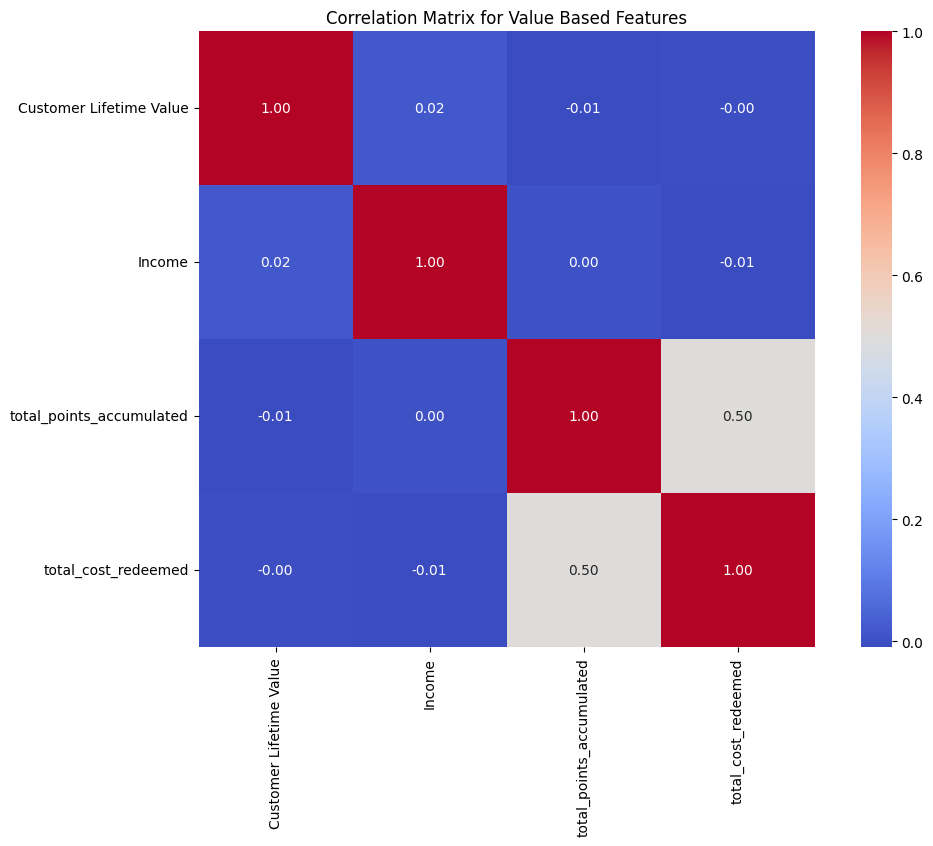

Pairs with correlation > 0.8 or < -0.8:
Series([], dtype: float64)


In [10]:
# Check for correlation inside the value based features
plt.figure(figsize=(12, 8))
correlation_matrix = df_value_based.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Value Based Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

### Algorithm Selection and Hyperparameter Tuning

We employ a comparative approach to identify the most robust clustering structure. We evaluate two distinct algorithms:
1.  **K-Means++:** A centroid-based algorithm efficient for large datasets.
2.  **Hierarchical Clustering:** A connectivity-based algorithm (using various linkage criteria: Ward, Complete, Average, Single).

We iterate through $k=2$ to $k=11$ clusters and assess performance using multiple metrics (R², Davies-Bouldin, Silhouette).


In [ ]:
# --- Comprehensive Clustering Evaluation with All Metrics ---

def evaluate_clustering_methods(data, feats, min_k=2, max_k=11):
    """
    Evaluates multiple clustering methods (K-Means and Hierarchical) across a range of K values.
    
    Parameters:
    -----------
    data : pd.DataFrame or np.array
        The dataset to cluster.
    feats : list
        List of feature names (used for R2 calculation).
    min_k : int
        Minimum number of clusters to test.
    max_k : int
        Maximum number of clusters to test (exclusive).
        
    Returns:
    --------
    dict
        A dictionary where keys are method names ('kmeans', 'ward', etc.) and values are DataFrames
        containing the evaluation metrics for each K.
    """
    
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) once for R2 calculation
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    # Initialize results dictionary
    results_by_method = {}
    
    # --- K-MEANS EVALUATION ---
    print("Evaluating K-Means...")
    kmeans_results = []
    kmeans_clusterer = KMeans(init='k-means++', n_init=20, random_state=42)
    
    for k in range(min_k, max_k):
        # Clone ensures we start with a fresh estimator each time
        kmeans = clone(kmeans_clusterer).set_params(n_clusters=k)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        dbi = davies_bouldin_score(X, labels)
        sil = silhouette_score(X, labels)
        
        kmeans_results.append({
            'K': k,
            'R2_Score': r2,
            'Davies_Bouldin': dbi,
            'Silhouette': sil,
            'Inertia': ssw
        })
    
    # Convert results to DataFrame and calculate percentage changes (Elbow method helper)
    df_kmeans = pd.DataFrame(kmeans_results)
    df_kmeans.loc[:, 'R2_Pct_Change'] = df_kmeans['R2_Score'].pct_change() * 100
    df_kmeans.loc[:, 'DBI_Pct_Change'] = df_kmeans['Davies_Bouldin'].pct_change() * 100
    df_kmeans.loc[:, 'Sil_Pct_Change'] = df_kmeans['Silhouette'].pct_change() * 100
    df_kmeans.loc[:, 'Inertia_Pct_Change'] = df_kmeans['Inertia'].pct_change() * 100
    
    results_by_method['kmeans'] = df_kmeans
    
    # --- HIERARCHICAL CLUSTERING EVALUATION (Various Linkages) ---
    hierarchical_clusterer = AgglomerativeClustering(metric='euclidean')
    
    for linkage_type in ['complete', 'average', 'single', 'ward']:
        print(f"Evaluating Hierarchical Clustering ({linkage_type})...")
        hc_results = []
        
        for k in range(min_k, max_k):
            hc = clone(hierarchical_clusterer).set_params(n_clusters=k, linkage=linkage_type)
            labels = hc.fit_predict(X)
            
            # Calculate metrics
            dbi = davies_bouldin_score(X, labels)
            sil = silhouette_score(X, labels)
            
            # Calculate R2 for hierarchical clustering (requires manual calculation as no inertia_)
            df_concat = pd.concat([data, pd.Series(labels, name='labels', index=data.index)], axis=1)
            r2 = get_rsq(df_concat, feats, 'labels')
            
            # Hierarchical clustering doesn't have inertia, so we'll use None
            hc_results.append({
                'K': k,
                'R2_Score': r2,
                'Davies_Bouldin': dbi,
                'Silhouette': sil,
                'Inertia': np.nan  # Not applicable for hierarchical clustering
            })
        
        df_hc = pd.DataFrame(hc_results)
        df_hc.loc[:, 'R2_Pct_Change'] = df_hc['R2_Score'].pct_change() * 100
        df_hc.loc[:, 'DBI_Pct_Change'] = df_hc['Davies_Bouldin'].pct_change() * 100
        df_hc.loc[:, 'Sil_Pct_Change'] = df_hc['Silhouette'].pct_change() * 100
        df_hc.loc[:, 'Inertia_Pct_Change'] = df_hc['Inertia'].pct_change() * 100
        
        results_by_method[linkage_type] = df_hc
    
    return results_by_method

# --- EXECUTION ---
print("Starting comprehensive clustering evaluation...\n")
clustering_results = evaluate_clustering_methods(df_value_based, value_based_features, min_k=2, max_k=11)

# --- DISPLAY RESULTS FOR EACH METHOD ---
for method_name, df_method in clustering_results.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name.upper()}")
    print(f"{'='*80}")
    display(df_method.round(4))
    
    # Highlight best K for each metric
    print(f"\nBest configurations for {method_name}:")
    print(f"  - Highest R2: K={df_method.loc[df_method['R2_Score'].idxmax(), 'K']:.0f}")
    print(f"  - Lowest Davies-Bouldin: K={df_method.loc[df_method['Davies_Bouldin'].idxmin(), 'K']:.0f}")
    print(f"  - Highest Silhouette: K={df_method.loc[df_method['Silhouette'].idxmax(), 'K']:.0f}")


Starting comprehensive clustering evaluation...

Evaluating K-Means...
Evaluating Hierarchical Clustering (complete)...
Evaluating Hierarchical Clustering (average)...
Evaluating Hierarchical Clustering (single)...
Evaluating Hierarchical Clustering (ward)...

METHOD: KMEANS


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.2603,1.4255,0.2705,48449.2482,NaN,NaN,NaN,NaN
1,3,0.3993,1.2300,0.2884,39348.5513,53.3742,-13.7128,6.6072,-18.7840
2,4,0.5215,1.1763,0.2881,31342.1023,30.6157,-4.3718,-0.1092,-20.3475
3,5,0.5999,1.0714,0.2802,26203.6775,15.0432,-8.9171,-2.7556,-16.3946
4,6,0.6465,1.0719,0.2729,23153.3640,7.7623,0.0506,-2.5931,-11.6408
5,7,0.6761,1.1203,0.2614,21216.8416,4.5730,4.5169,-4.1966,-8.3639
6,8,0.6982,1.1860,0.2636,19768.7556,3.2701,5.8648,0.8258,-6.8252
7,9,0.7167,1.2533,0.2499,18555.8196,2.6523,5.6707,-5.2138,-6.1356
8,10,0.7339,1.1854,0.2550,17427.2310,2.4041,-5.4134,2.0511,-6.0821



Best configurations for kmeans:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=5
  - Highest Silhouette: K=3

METHOD: COMPLETE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.0380,0.5363,0.6605,NaN,NaN,NaN,NaN,NaN
1,3,0.1849,1.1491,0.2117,NaN,386.5827,114.2719,-67.9416,NaN
2,4,0.2663,1.2494,0.2241,NaN,43.9989,8.7305,5.8518,NaN
3,5,0.2700,1.3375,0.2167,NaN,1.4056,7.0451,-3.3273,NaN
4,6,0.2711,1.3918,0.2161,NaN,0.3990,4.0591,-0.2471,NaN
5,7,0.3119,1.4070,0.1819,NaN,15.0447,1.0970,-15.8514,NaN
6,8,0.3207,1.4159,0.1557,NaN,2.8198,0.6276,-14.3820,NaN
7,9,0.4084,1.4275,0.1271,NaN,27.3532,0.8253,-18.3461,NaN
8,10,0.4165,1.3595,0.1278,NaN,1.9862,-4.7659,0.5344,NaN



Best configurations for complete:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: AVERAGE


...


Best configurations for average:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: SINGLE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.0012,0.2091,0.7024,NaN,NaN,NaN,NaN,NaN
1,3,0.0027,0.2015,0.7024,NaN,125.6657,-3.6305,0.0062,NaN
2,4,0.0045,0.3285,0.6683,NaN,69.8813,63.0077,-4.8665,NaN
3,5,0.0061,0.2996,0.6682,NaN,33.4665,-8.7769,-0.0107,NaN
4,6,0.0073,0.3016,0.6682,NaN,20.0506,0.6420,-0.0008,NaN
5,7,0.0111,0.2880,0.6685,NaN,52.4129,-4.5041,0.0466,NaN
6,8,0.0111,0.2107,0.6638,NaN,0.1842,-26.8441,-0.7066,NaN
7,9,0.0124,0.2097,0.6636,NaN,11.3758,-0.4868,-0.0183,NaN
8,10,0.0152,0.2806,0.6639,NaN,22.5046,33.8286,0.0366,NaN



Best configurations for single:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=3
  - Highest Silhouette: K=3

METHOD: WARD


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.2186,1.3422,0.2386,NaN,NaN,NaN,NaN,NaN
1,3,0.3656,1.3357,0.2684,NaN,67.2438,-0.4870,12.5198,NaN
2,4,0.4511,1.3946,0.2252,NaN,23.4010,4.4146,-16.1165,NaN
3,5,0.5262,1.3024,0.2062,NaN,16.6522,-6.6138,-8.4199,NaN
4,6,0.5754,1.2175,0.2073,NaN,9.3371,-6.5218,0.5232,NaN
5,7,0.6114,1.2995,0.2142,NaN,6.2539,6.7396,3.3459,NaN
6,8,0.6430,1.2598,0.2063,NaN,5.1752,-3.0522,-3.7009,NaN
7,9,0.6684,1.3345,0.1892,NaN,3.9440,5.9263,-8.2885,NaN
8,10,0.6860,1.2832,0.1928,NaN,2.6444,-3.8453,1.8753,NaN



Best configurations for ward:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=6
  - Highest Silhouette: K=3


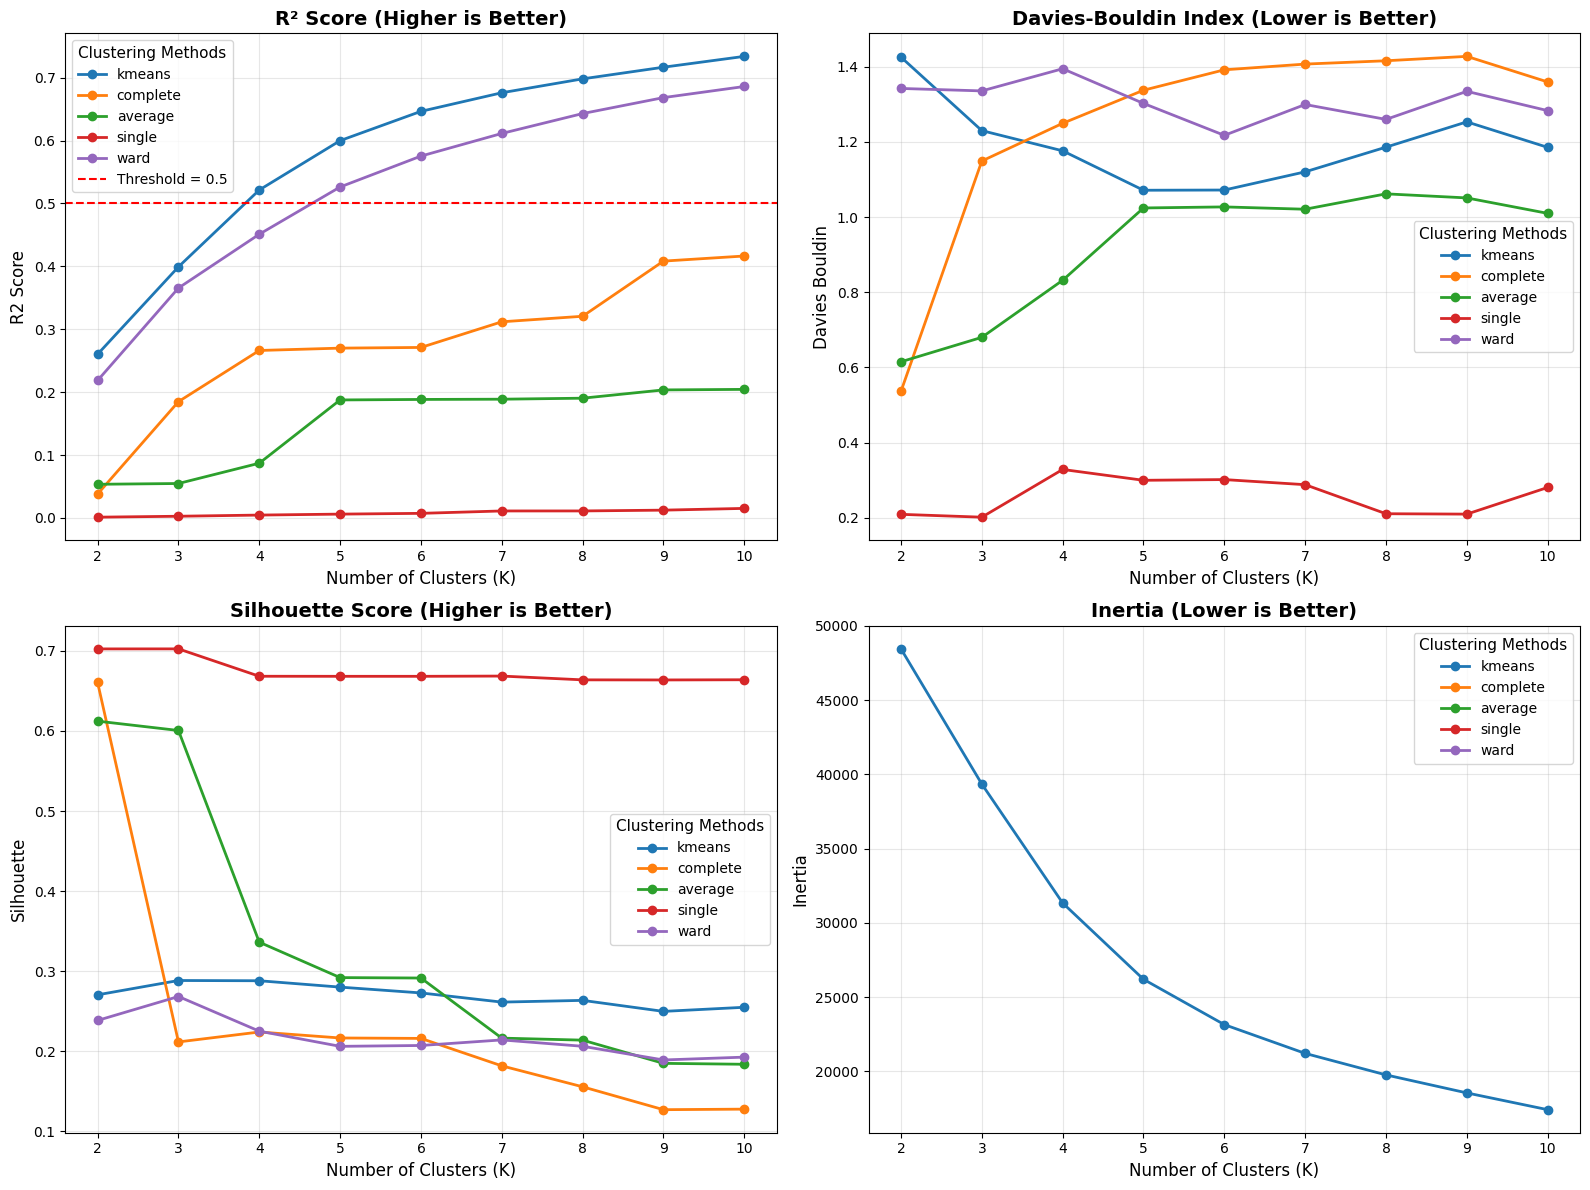

In [12]:
# --- Visualization: 4 Subplots (One per Metric, All Methods) ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
metrics_data = {
    'R2_Score': axes[0, 0],
    'Davies_Bouldin': axes[0, 1],
    'Silhouette': axes[1, 0],
    'Inertia': axes[1, 1]
}

metric_labels = {
    'R2_Score': 'R² Score (Higher is Better)',
    'Davies_Bouldin': 'Davies-Bouldin Index (Lower is Better)',
    'Silhouette': 'Silhouette Score (Higher is Better)',
    'Inertia': 'Inertia (Lower is Better)'
}

# Plot each metric
for metric_name, ax in metrics_data.items():
    for method_name, df_method in clustering_results.items():
        ax.plot(df_method['K'], df_method[metric_name], marker='o', label=method_name, linewidth=2)
    
    ax.set_title(metric_labels[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel(metric_name.replace('_', ' '), fontsize=12)
    ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))

    # Add horizontal threshold line for R² Score
    if metric_name == 'R2_Score':
        ax.axhline(y=0.5, color='r', linestyle='--', label='Threshold = 0.5')
        ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


### Selection of the Optimal Solution (Value-Based)

After analyzing the evaluation plots, we select **K-Means with K=4** as the optimal solution.

**Justification:**
*   **Elbow Method (Inertia/R²):** We observe a distinct 'elbow' at K=4, where the marginal gain in variance explanation diminishes.
*   **Silhouette Score:** The score remains relatively high at K=4, indicating well-separated clusters.
*   **Interpretability:** Preliminary profiling suggests that 4 clusters provide distinct and actionable tiers (e.g., High Value, Low Value, etc.) without over-segmenting.


In [13]:
# 1. Perform final clustering
k_best_value = 4

kmeans_value = KMeans(n_clusters=k_best_value, init='k-means++', n_init=20, random_state=42)

value_labels = kmeans_value.fit_predict(df_value_based)

customers['valuebased_cluster'] = value_labels

In [14]:
df_profile_value = df_value_based.copy()
df_profile_value['Cluster'] = value_labels

df_profile_value

,Customer Lifetime Value,Income,total_points_accumulated,total_cost_redeemed,Cluster
Loyalty#,,,,,
480934,-0.605614,1.068659,1.338311,0.576033,0
549612,-0.605545,-1.243243,0.843514,1.584071,3
429460,-0.605524,-1.243243,-0.317841,-0.369294,3
608370,-0.605524,-1.243243,0.592203,0.896561,3
530508,-0.605080,1.981146,0.488700,-0.987124,0
...,...,...,...,...,...
823768,7.874405,-1.243243,0.770479,-0.987124,2
680886,8.759826,1.337732,0.447844,0.902368,2
776187,9.683862,-1.243243,1.210686,0.828042,2


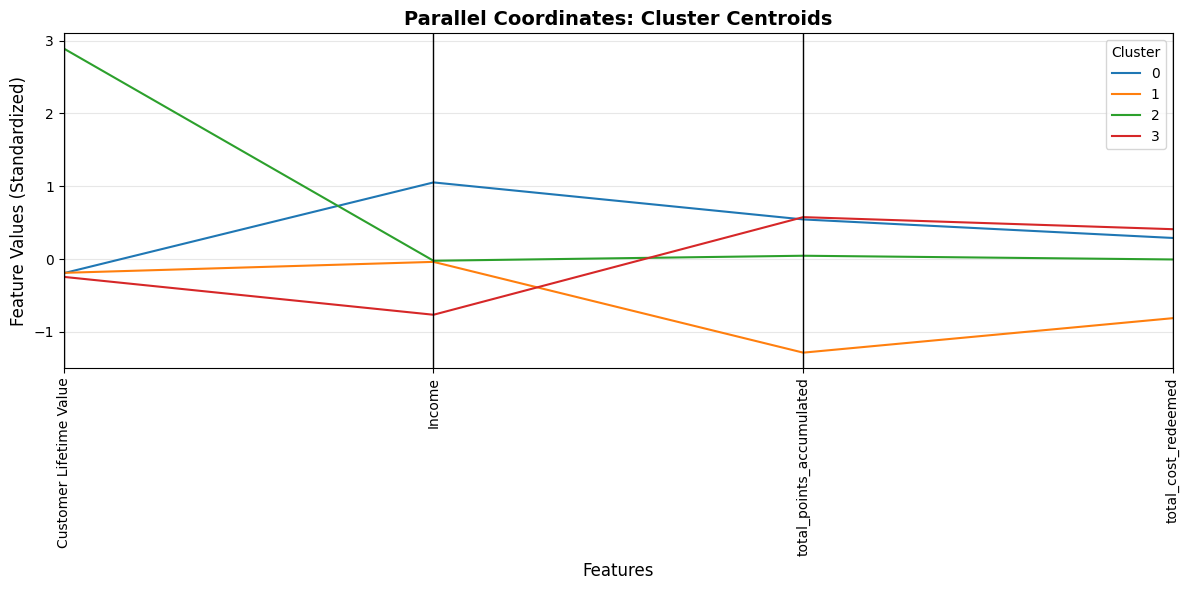

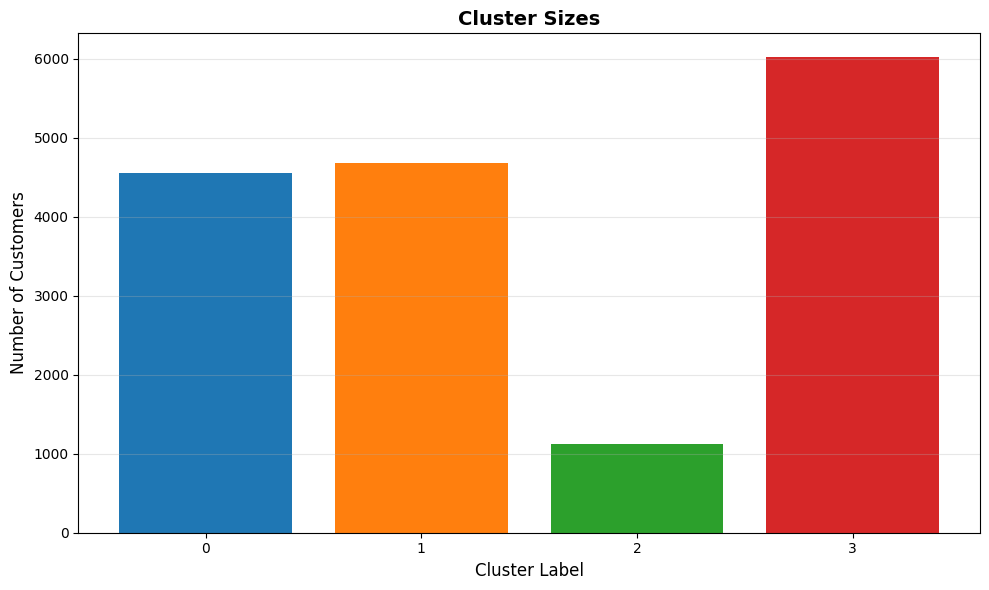

In [15]:
# Value based cluster profiling
df_profile_value = df_value_based.copy()
df_profile_value['Cluster'] = value_labels

# 3. Calculate Centroids (Average values per cluster)
df_centroids_value = df_profile_value.groupby('Cluster')[value_based_features].mean()

# --- Visualization 1: Parallel Coordinates ---
plt.figure(figsize=(12, 6))

# Parallel coordinates
pd.plotting.parallel_coordinates(
    df_centroids_value.reset_index(),
    'Cluster',
    color=sns.color_palette('tab10', n_colors=k_best_value)
)
plt.title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
plt.ylabel('Feature Values (Standardized)', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

# --- Visualization 2: Cluster Sizes ---
plt.figure(figsize=(10, 6))
cluster_sizes = df_profile_value['Cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best_value)

plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
plt.xlabel('Cluster Label', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Cluster Sizes', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

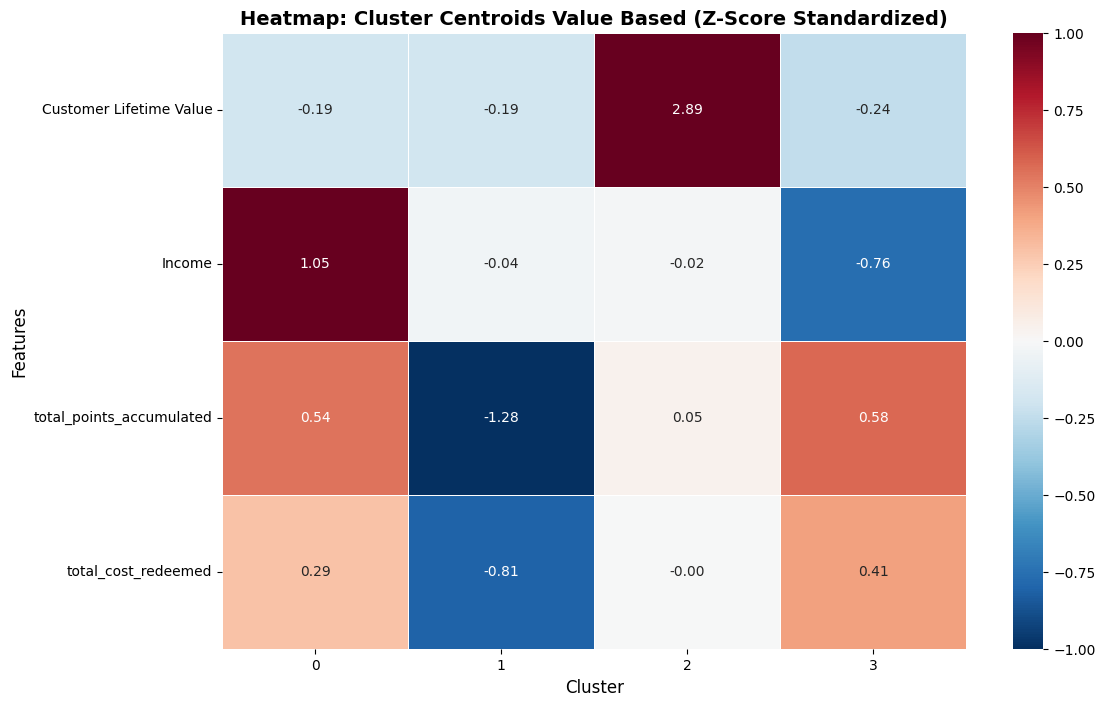

In [16]:
# --- Visualization 2: Heatmap of Centroids ---
plt.figure(figsize=(12, 8))

# Prepare data: Features as rows
df_plot = df_centroids_value.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0,       # Centered at 0 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=-1,        # Minimum at -1
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids Value Based (Z-Score Standardized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

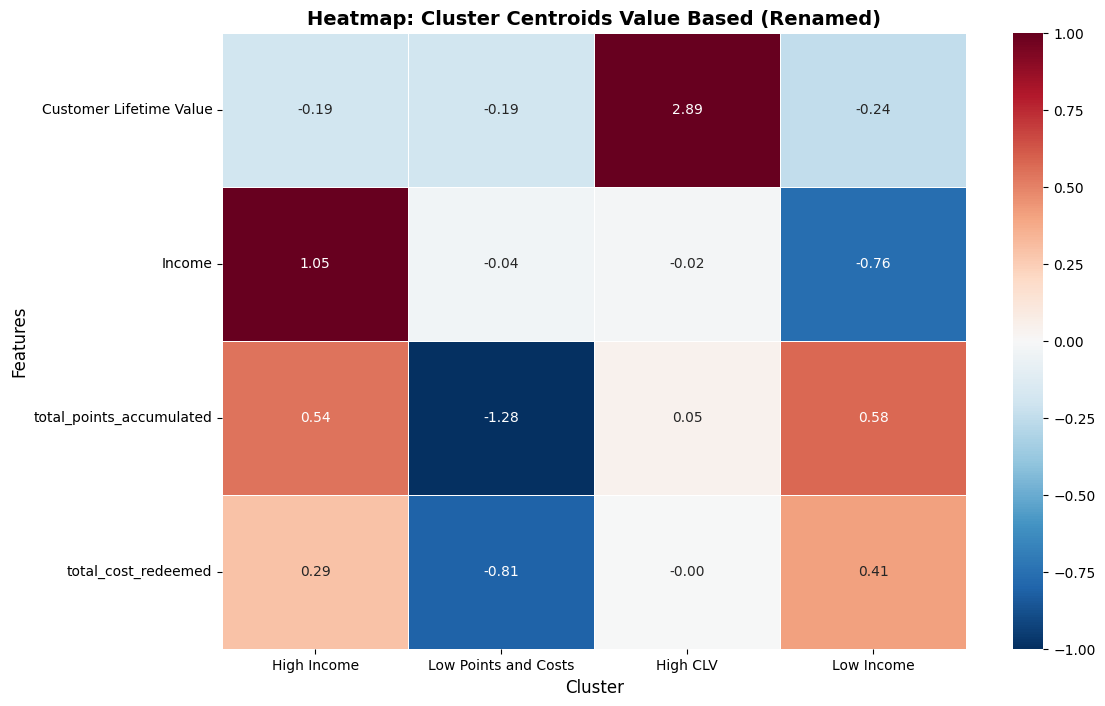

In [17]:
# --- Visualization 2: Heatmap of Centroids (Renamed) ---
plt.figure(figsize=(12, 8))

# Rename clusters
df_centroids_value_renamed = df_centroids_value.rename(index={
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
})

# Prepare data: Features as rows
df_plot = df_centroids_value_renamed.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0,       # Centered at 0 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=-1,        # Minimum at -1
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids Value Based (Renamed)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

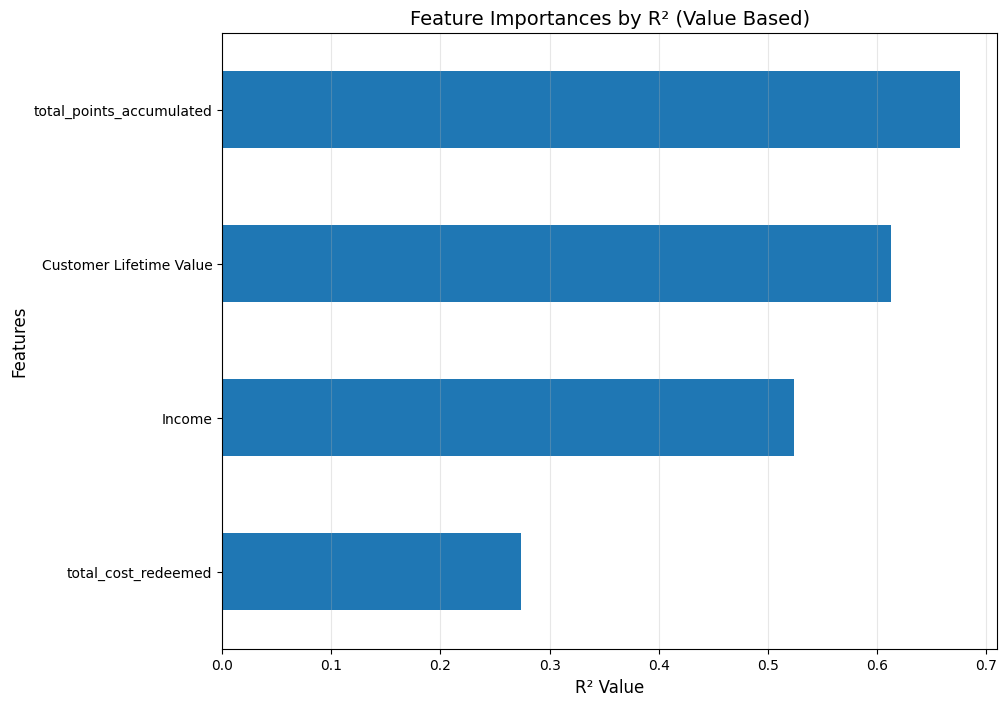

In [18]:
# Since 'r2_variables' is not defined, we calculate R2 for each feature individually
# using the existing 'get_rsq' function.
r2_data = {}
for feature in value_based_features:
    # get_rsq expects a list of features, hence [feature]
    r2_data[feature] = get_rsq(df_profile_value, [feature], 'Cluster')

r2_feats = pd.Series(r2_data)

# Plotting
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Value Based)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

## 2.2 Demographic Clustering

### Feature Selection: Demographic Perspective

For the second dimension, we focus on **customer profile attributes**. These features help us understand *who* the customers are, independent of their spending.

**Selected Features:**
*   **Location** 
*   **Education** 
*   **Marital Status** 
*   **Gender**


In [19]:
# Print number of metric features   
print ("Number of metric features:", len(demographic_features))

# check if metric or not 

for feature in demographic_features:
    if pd.api.types.is_numeric_dtype(customers[feature]):
        print(f"{feature}: Metric")
    else:
        print(f"{feature}: Not Metric")


# Create the pandas dataframe df_demographic
df_demographic = pd.DataFrame(customers[demographic_features])

df_demographic.head()

Number of metric features: 9
Location Code_Suburban: Metric
Location Code_Urban: Metric
Gender_male: Metric
Education_College: Metric
Education_High School or Below: Metric
Education_Master: Metric
Education_Doctor: Metric
Marital Status_Married: Metric
Marital Status_Single: Metric


,Location Code_Suburban,Location Code_Urban,Gender_male,Education_College,Education_High School or Below,Education_Master,Education_Doctor,Marital Status_Married,Marital Status_Single
Loyalty#,,,,,,,,,
480934,-0.716227,1.437326,-0.995430,-0.582545,-0.221224,-0.177105,-0.213677,0.846863,-0.605314
549612,-0.716227,-0.695737,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,-0.605314
429460,-0.716227,1.437326,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,1.652035
608370,1.396205,-0.695737,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,1.652035
530508,1.396205,-0.695737,1.004591,-0.582545,-0.221224,-0.177105,-0.213677,0.846863,-0.605314


### Multicollinearity Check (Demographic)

Similar to the value-based approach, we check for high correlations among demographic variables. This is particularly important for dummy-encoded variables where structural correlations might exist.


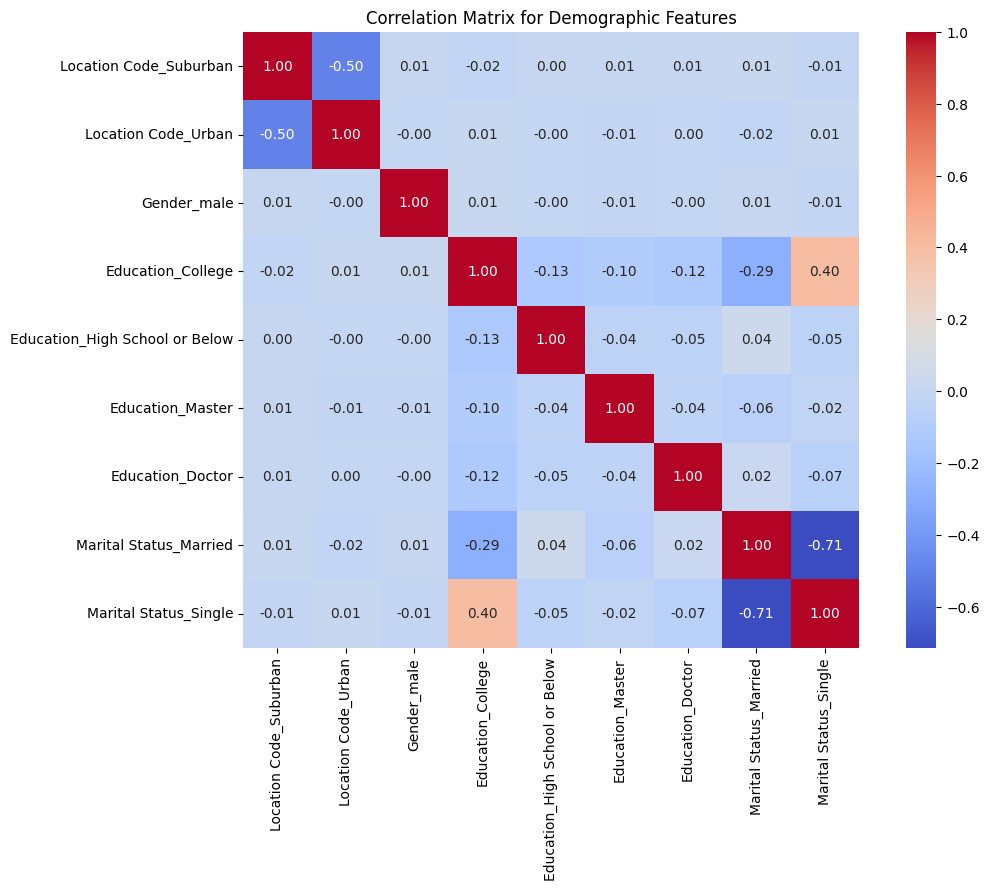

Pairs with correlation > 0.8 or < -0.8:
Series([], dtype: float64)


In [20]:
# Check for correlation inside the value based features
plt.figure(figsize=(12, 8))
correlation_matrix = df_demographic.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix for Demographic Features")
plt.show()

threshold = 0.8
unstacked = correlation_matrix.unstack()
high_corr = unstacked[(unstacked.abs() > threshold) & (unstacked != 1.0)].drop_duplicates()

print(f"Pairs with correlation > {threshold} or < -{threshold}:")
print(high_corr)

### Algorithm Selection and Hyperparameter Tuning

We repeat the comprehensive evaluation process for the demographic dataset, comparing K-Means and Hierarchical Clustering across $k=2$ to $k=11$.


In [21]:
# --- Comprehensive Clustering Evaluation with All Metrics ---

def evaluate_clustering_methods(data, feats, min_k=2, max_k=11):
    """
    Evaluates multiple clustering methods and calculates:
    - R2 Score
    - Davies-Bouldin Index (DBI)
    - Silhouette Score
    - Inertia (for KMeans-based methods)
    
    Returns a dictionary with DataFrames for each method.
    """
    
    X = data.values if isinstance(data, pd.DataFrame) else data
    
    # Calculate Total Sum of Squares (SST) once for R2 calculation
    centroid = X.mean(axis=0)
    sst = np.sum((X - centroid) ** 2)
    
    # Initialize results dictionary
    results_by_method = {}
    
    # --- K-MEANS ---
    print("Evaluating K-Means...")
    kmeans_results = []
    kmeans_clusterer = KMeans(init='k-means++', n_init=20, random_state=42)
    
    for k in range(min_k, max_k):
        kmeans = clone(kmeans_clusterer).set_params(n_clusters=k)
        labels = kmeans.fit_predict(X)
        
        # Calculate metrics
        ssw = kmeans.inertia_
        r2 = 1 - (ssw / sst)
        dbi = davies_bouldin_score(X, labels)
        sil = silhouette_score(X, labels)
        
        kmeans_results.append({
            'K': k,
            'R2_Score': r2,
            'Davies_Bouldin': dbi,
            'Silhouette': sil,
            'Inertia': ssw
        })
    
    df_kmeans = pd.DataFrame(kmeans_results)
    df_kmeans.loc[:, 'R2_Pct_Change'] = df_kmeans['R2_Score'].pct_change() * 100
    df_kmeans.loc[:, 'DBI_Pct_Change'] = df_kmeans['Davies_Bouldin'].pct_change() * 100
    df_kmeans.loc[:, 'Sil_Pct_Change'] = df_kmeans['Silhouette'].pct_change() * 100
    df_kmeans.loc[:, 'Inertia_Pct_Change'] = df_kmeans['Inertia'].pct_change() * 100
    
    results_by_method['kmeans'] = df_kmeans
    
    # --- HIERARCHICAL CLUSTERING (Various Linkages) ---
    hierarchical_clusterer = AgglomerativeClustering(metric='euclidean')
    
    for linkage_type in ['complete', 'average', 'single', 'ward']:
        print(f"Evaluating Hierarchical Clustering ({linkage_type})...")
        hc_results = []
        
        for k in range(min_k, max_k):
            hc = clone(hierarchical_clusterer).set_params(n_clusters=k, linkage=linkage_type)
            labels = hc.fit_predict(X)
            
            # Calculate metrics
            dbi = davies_bouldin_score(X, labels)
            sil = silhouette_score(X, labels)
            
            # Calculate R2 for hierarchical clustering
            df_concat = pd.concat([data, pd.Series(labels, name='labels', index=data.index)], axis=1)
            r2 = get_rsq(df_concat, feats, 'labels')
            
            # Hierarchical clustering doesn't have inertia, so we'll use None
            hc_results.append({
                'K': k,
                'R2_Score': r2,
                'Davies_Bouldin': dbi,
                'Silhouette': sil,
                'Inertia': np.nan  # Not applicable for hierarchical clustering
            })
        
        df_hc = pd.DataFrame(hc_results)
        df_hc.loc[:, 'R2_Pct_Change'] = df_hc['R2_Score'].pct_change() * 100
        df_hc.loc[:, 'DBI_Pct_Change'] = df_hc['Davies_Bouldin'].pct_change() * 100
        df_hc.loc[:, 'Sil_Pct_Change'] = df_hc['Silhouette'].pct_change() * 100
        df_hc.loc[:, 'Inertia_Pct_Change'] = df_hc['Inertia'].pct_change() * 100
        
        results_by_method[linkage_type] = df_hc
    
    return results_by_method

# --- EXECUTION ---
print("Starting comprehensive clustering evaluation...\n")
clustering_results_demographic = evaluate_clustering_methods(df_demographic, demographic_features, min_k=2, max_k=11)

# --- DISPLAY RESULTS FOR EACH METHOD ---
for method_name, df_method in clustering_results_demographic.items():
    print(f"\n{'='*80}")
    print(f"METHOD: {method_name.upper()}")
    print(f"{'='*80}")
    display(df_method.round(4))
    
    # Highlight best K for each metric
    print(f"\nBest configurations for {method_name}:")
    print(f"  - Highest R2: K={df_method.loc[df_method['R2_Score'].idxmax(), 'K']:.0f}")
    print(f"  - Lowest Davies-Bouldin: K={df_method.loc[df_method['Davies_Bouldin'].idxmin(), 'K']:.0f}")
    print(f"  - Highest Silhouette: K={df_method.loc[df_method['Silhouette'].idxmax(), 'K']:.0f}")

Starting comprehensive clustering evaluation...

Evaluating K-Means...
Evaluating Hierarchical Clustering (complete)...
Evaluating Hierarchical Clustering (average)...
Evaluating Hierarchical Clustering (single)...
Evaluating Hierarchical Clustering (ward)...

METHOD: KMEANS


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.1890,1.6968,0.2541,119517.1235,NaN,NaN,NaN,NaN
1,3,0.2978,1.3789,0.2875,103484.3757,57.5519,-18.7334,13.1395,-13.4146
2,4,0.4048,1.2040,0.3204,87719.2270,35.9192,-12.6874,11.4662,-15.2343
3,5,0.4936,1.2174,0.3069,74634.5015,21.9337,1.1187,-4.2075,-14.9166
4,6,0.6000,1.0447,0.3353,58955.3293,21.5549,-14.1900,9.2383,-21.0079
5,7,0.6467,1.0577,0.3524,52062.2614,7.7959,1.2446,5.0976,-11.6920
6,8,0.6820,1.1477,0.3719,46865.7428,5.4521,8.5124,5.5484,-9.9814
7,9,0.7122,1.0906,0.4033,42408.8761,4.4343,-4.9731,8.4186,-9.5099
8,10,0.7350,1.0034,0.4389,39057.6157,3.1927,-7.9977,8.8481,-7.9023



Best configurations for kmeans:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=10
  - Highest Silhouette: K=10

METHOD: COMPLETE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.1131,0.8308,0.4605,NaN,NaN,NaN,NaN,NaN
1,3,0.2268,0.8995,0.4211,NaN,100.4717,8.2707,-8.5519,NaN
2,4,0.3400,0.9007,0.4415,NaN,49.9418,0.1317,4.8332,NaN
3,5,0.5121,1.0431,0.3498,NaN,50.6160,15.8118,-20.7589,NaN
4,6,0.5995,1.0512,0.3348,NaN,17.0632,0.7774,-4.3018,NaN
5,7,0.6054,1.1539,0.3291,NaN,0.9792,9.7672,-1.7008,NaN
6,8,0.6092,1.2539,0.3214,NaN,0.6246,8.6684,-2.3395,NaN
7,9,0.6127,1.3713,0.3136,NaN,0.5742,9.3629,-2.4248,NaN
8,10,0.6473,1.3886,0.3182,NaN,5.6468,1.2626,1.4821,NaN



Best configurations for complete:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: AVERAGE


...


Best configurations for average:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: SINGLE


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.1131,0.8308,0.4605,NaN,NaN,NaN,NaN,NaN
1,3,0.2268,0.8995,0.4211,NaN,100.4717,8.2707,-8.5519,NaN
2,4,0.3400,0.9007,0.4415,NaN,49.9418,0.1317,4.8332,NaN
3,5,0.4724,1.1743,0.3039,NaN,38.9398,30.3718,-31.1518,NaN
4,6,0.4759,1.3539,0.2957,NaN,0.7404,15.2988,-2.7121,NaN
5,7,0.4797,1.4293,0.2870,NaN,0.7945,5.5675,-2.9386,NaN
6,8,0.4856,1.4623,0.2801,NaN,1.2237,2.3083,-2.3932,NaN
7,9,0.5386,1.4459,0.2466,NaN,10.9278,-1.1195,-11.9719,NaN
8,10,0.6135,1.4567,0.2939,NaN,13.8930,0.7441,19.1685,NaN



Best configurations for single:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=2
  - Highest Silhouette: K=2

METHOD: WARD


,K,R2_Score,Davies_Bouldin,Silhouette,Inertia,R2_Pct_Change,DBI_Pct_Change,Sil_Pct_Change,Inertia_Pct_Change
0,2,0.1771,1.6017,0.2332,NaN,NaN,NaN,NaN,NaN
1,3,0.2905,1.2869,0.2684,NaN,64.0825,-19.6529,15.0907,NaN
2,4,0.4018,1.1515,0.3095,NaN,38.2867,-10.5217,15.3211,NaN
3,5,0.5121,1.0431,0.3498,NaN,27.4664,-9.4150,13.0408,NaN
4,6,0.5828,1.0834,0.3086,NaN,13.7942,3.8592,-11.7931,NaN
5,7,0.6372,1.0912,0.3468,NaN,9.3465,0.7263,12.4022,NaN
6,8,0.6713,1.1374,0.3587,NaN,5.3514,4.2271,3.4248,NaN
7,9,0.7054,1.1104,0.3768,NaN,5.0747,-2.3669,5.0489,NaN
8,10,0.7312,1.0675,0.4117,NaN,3.6548,-3.8692,9.2446,NaN



Best configurations for ward:
  - Highest R2: K=10
  - Lowest Davies-Bouldin: K=5
  - Highest Silhouette: K=10


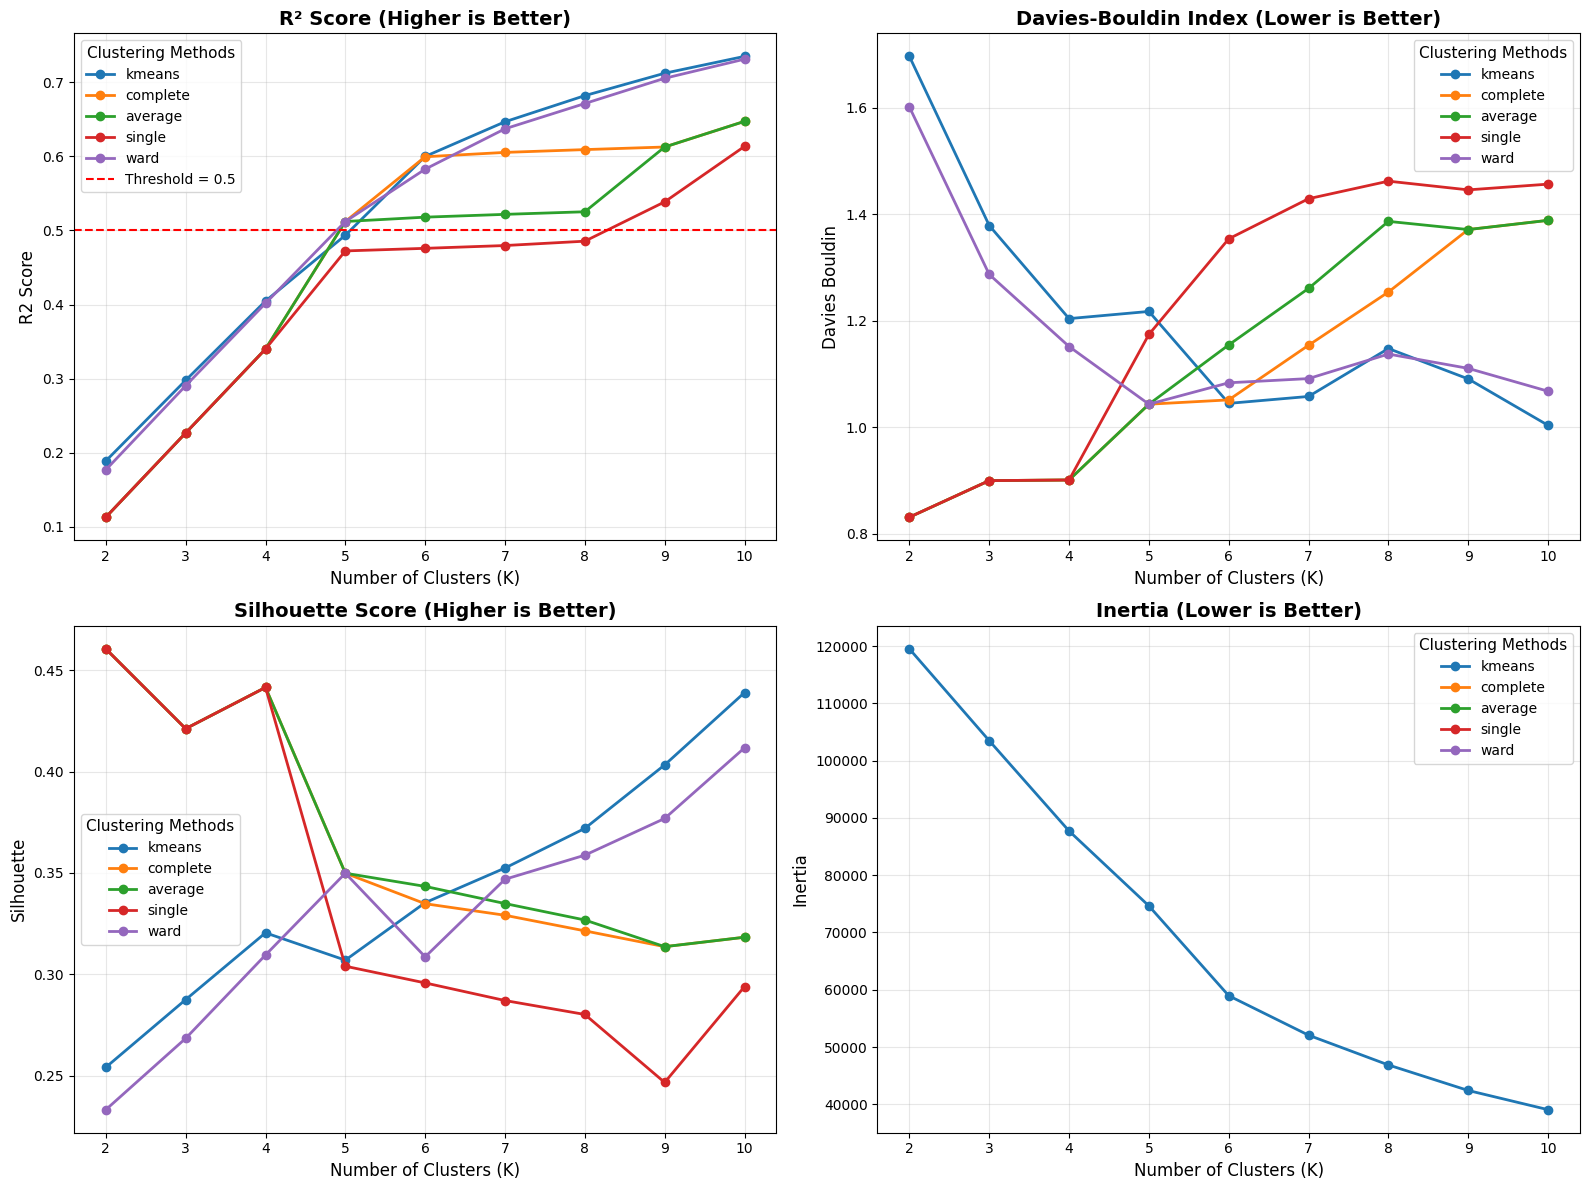

In [22]:
# --- Visualization: 4 Subplots (One per Metric, All Methods) ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for plotting
metrics_data = {
    'R2_Score': axes[0, 0],
    'Davies_Bouldin': axes[0, 1],
    'Silhouette': axes[1, 0],
    'Inertia': axes[1, 1]
}

metric_labels = {
    'R2_Score': 'R² Score (Higher is Better)',
    'Davies_Bouldin': 'Davies-Bouldin Index (Lower is Better)',
    'Silhouette': 'Silhouette Score (Higher is Better)',
    'Inertia': 'Inertia (Lower is Better)'
}

# Plot each metric
for metric_name, ax in metrics_data.items():
    for method_name, df_method in clustering_results_demographic.items():
        ax.plot(df_method['K'], df_method[metric_name], marker='o', label=method_name, linewidth=2)
    
    ax.set_title(metric_labels[metric_name], fontsize=14, fontweight='bold')
    ax.set_xlabel('Number of Clusters (K)', fontsize=12)
    ax.set_ylabel(metric_name.replace('_', ' '), fontsize=12)
    ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(2, 11))

    # Add horizontal threshold line for R² Score
    if metric_name == 'R2_Score':
        ax.axhline(y=0.5, color='r', linestyle='--', label='Threshold = 0.5')
        ax.legend(title='Clustering Methods', title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


### Selection of the Optimal Solution (Demographic)

We select **K-Means with K=6** for the demographic segmentation.

**Justification:**
*   **R² Score:** The R² value exceeds 0.5 at K=6, indicating that the clusters explain more than 50% of the variance in the demographic data.
*   **Elbow Analysis:** The inertia plot shows a noticeable inflection point around K=6.
*   **Distinct Profiles:** With 6 clusters, we are able to capture distinct life-stage segments (e.g., 'Single College Students' vs. 'Married Urban Professionals') that would be merged in a smaller K solution.


In [23]:
# 1. Perform final clustering
k_best_demo = 6

kmeans_demo = KMeans(n_clusters=k_best_demo, init='k-means++', n_init=20, random_state=42)

demo_labels = kmeans_demo.fit_predict(df_demographic)

customers['demographic_cluster'] = demo_labels

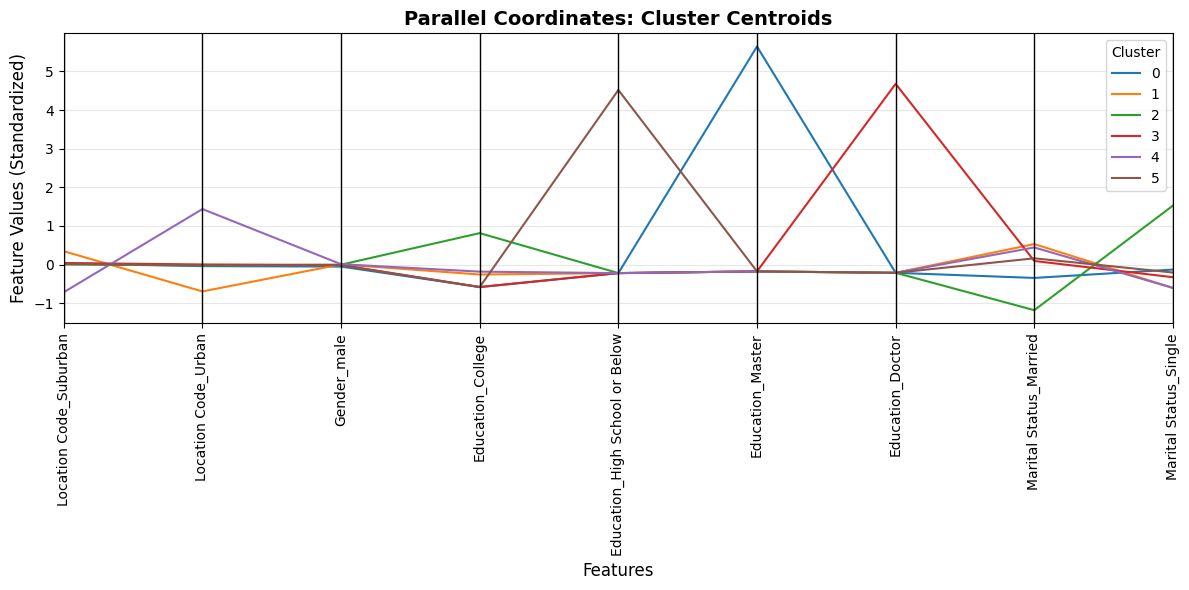

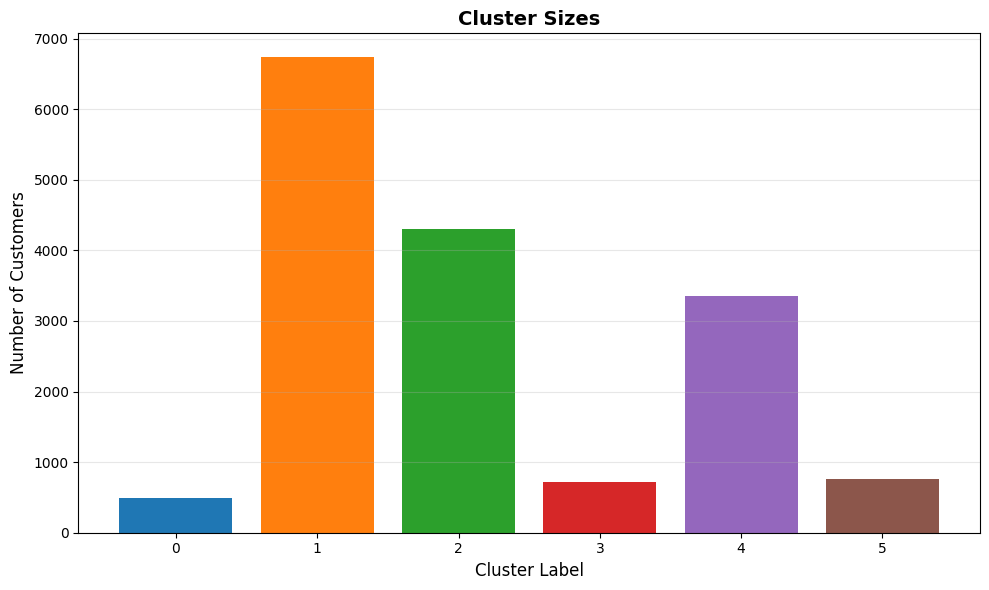

In [24]:
# Demographic cluster profiling
df_profile_demo = df_demographic.copy()
df_profile_demo['cluster'] = demo_labels

# 3. Calculate Centroids (Average values per cluster)
df_centroids_demo = df_profile_demo.groupby('cluster')[demographic_features].mean()

# --- Visualization 1: Parallel Coordinates ---
plt.figure(figsize=(12, 6))

# Parallel coordinates
pd.plotting.parallel_coordinates(
    df_centroids_demo.reset_index(),
    'cluster',
    color=sns.color_palette('tab10', n_colors=k_best_demo)
)
plt.title('Parallel Coordinates: Cluster Centroids', fontsize=14, fontweight='bold')
plt.ylabel('Feature Values (Standardized)', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

# --- Visualization 2: Cluster Sizes ---
plt.figure(figsize=(10, 6))
cluster_sizes = df_profile_demo['cluster'].value_counts().sort_index()
colors = sns.color_palette('tab10', n_colors=k_best_demo)

plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color=colors)
plt.xlabel('Cluster Label', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Cluster Sizes', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

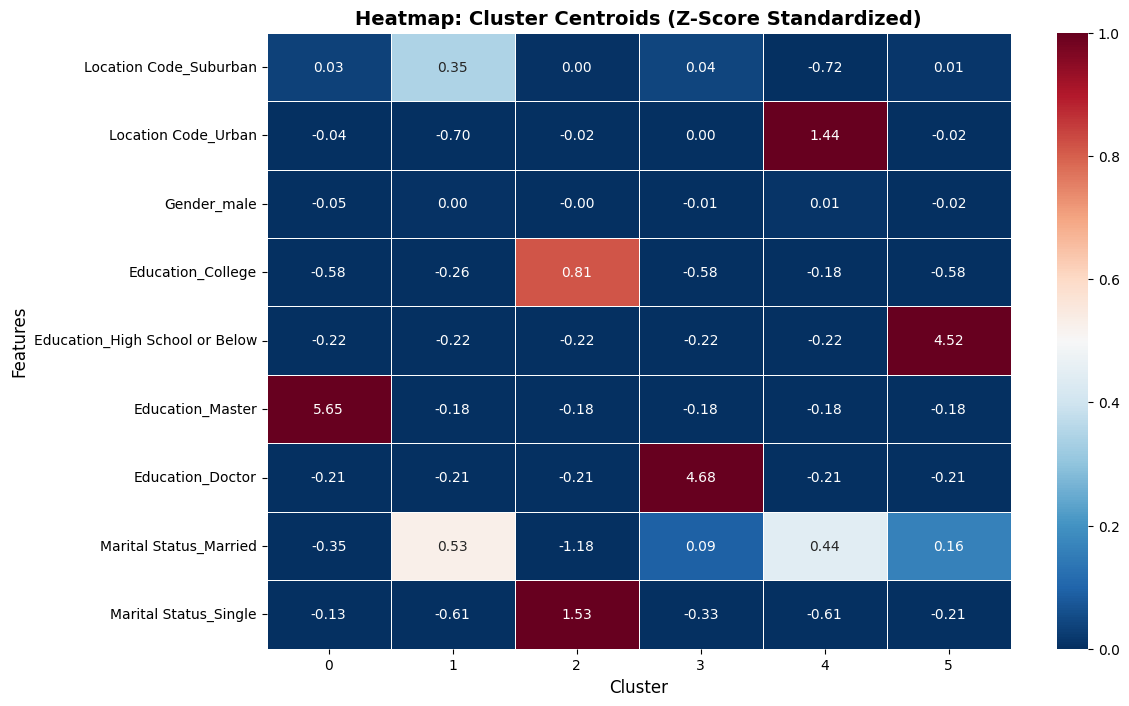

In [25]:
# --- Visualization 2: Heatmap of Centroids ---
plt.figure(figsize=(12, 8))

# Prepare data: Features as rows
df_plot = df_centroids_demo.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0.5,     # Centered at 0.5 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=0,         # Minimum at 0
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids (Z-Score Standardized)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

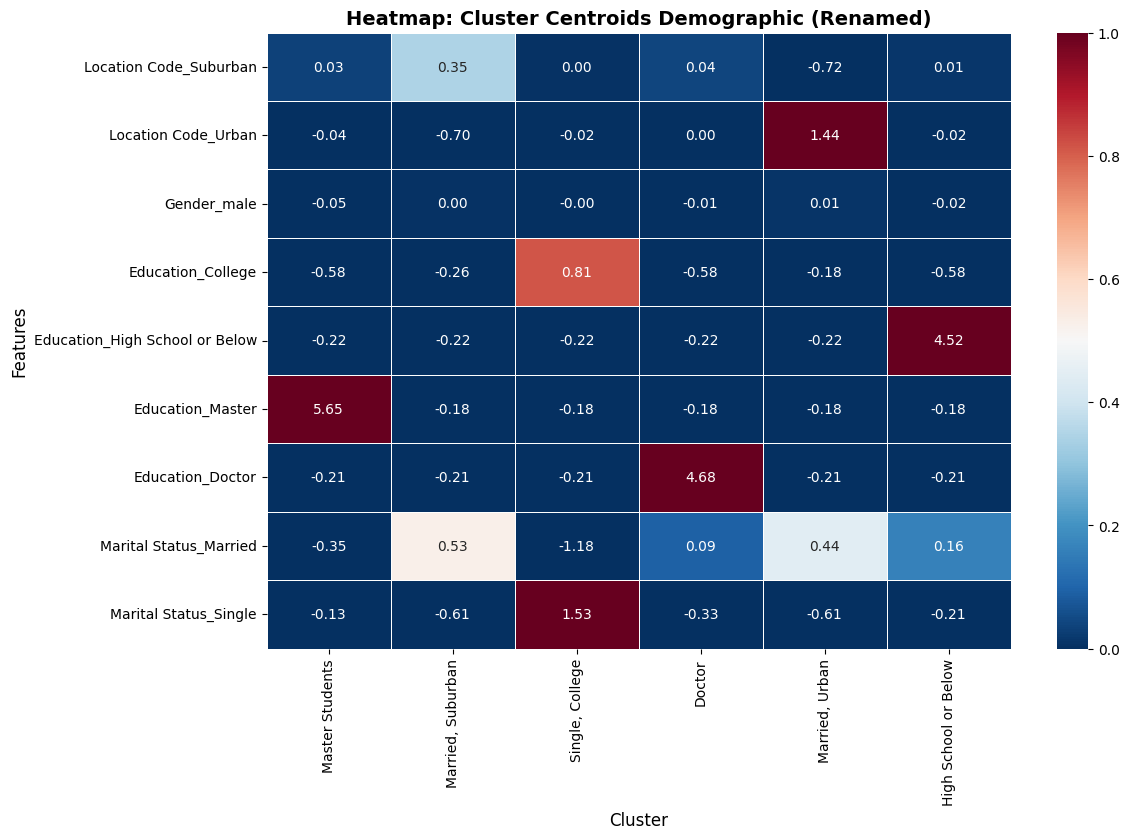

In [26]:
# --- Visualization 2: Heatmap of Centroids (Renamed) ---
plt.figure(figsize=(12, 8))

# Rename clusters
df_centroids_demo_renamed = df_centroids_demo.rename(index={
    0: 'Master Students',
    1: 'Married, Suburban',
    2: 'Single, College',
    3: 'Doctor',
    4: 'Married, Urban',
    5: 'High School or Below'
})

# Prepare data: Features as rows
df_plot = df_centroids_demo_renamed.T

# Transpose (T) so that features are on the Y-axis
sns.heatmap(
    df_plot, 
    cmap='RdBu_r',  # Red-Blue colormap (good for deviations from the mean)
    center=0.5,     # Centered at 0.5 for standardized data
    annot=True,     # Show values
    fmt='.2f',      # 2 decimal places
    linewidths=.5,
    vmin=0,         # Minimum at 0
    vmax=1          # Maximum at 1
)

plt.title('Heatmap: Cluster Centroids Demographic (Renamed)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

Number of customers in each cluster:
Cluster Master Students: 498 customers
Cluster Married, Suburban: 6739 customers
Cluster Single, College: 4303 customers
Cluster Doctor: 715 customers
Cluster Married, Urban: 3356 customers
Cluster High School or Below: 764 customers


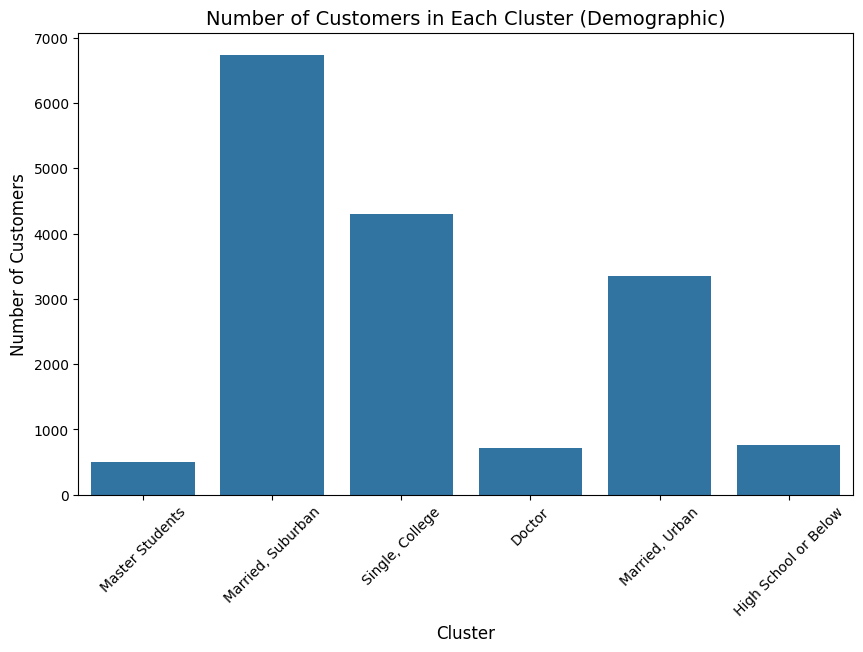

In [27]:
# Define cluster names
demo_cluster_names = {
    0: 'Master Students',
    1: 'Married, Suburban',
    2: 'Single, College',
    3: 'Doctor',
    4: 'Married, Urban',
    5: 'High School or Below'
}

# Count the number of customers in each cluster and display the result and plot it
cluster_counts = df_profile_demo['cluster'].value_counts().sort_index()

# Rename the index
cluster_counts.index = cluster_counts.index.map(demo_cluster_names)

print("Number of customers in each cluster:")
for cluster_label, count in cluster_counts.items():
    print(f"Cluster {cluster_label}: {count} customers")

plt.figure(figsize=(10, 6))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
plt.title('Number of Customers in Each Cluster (Demographic)', fontsize=14)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45)
plt.show()

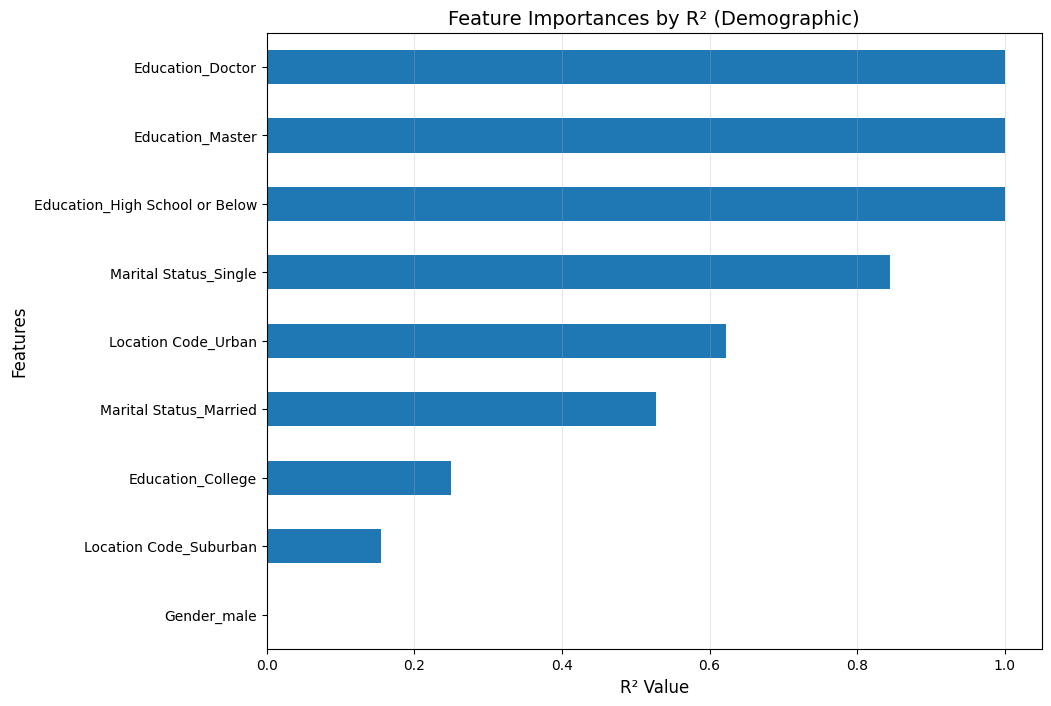

In [28]:
# Since 'r2_variables' is not defined, we calculate R2 for each feature individually
# using the existing 'get_rsq' function.
r2_data = {}
for feature in demographic_features:
    # get_rsq expects a list of features, hence [feature]
    r2_data[feature] = get_rsq(df_profile_demo, [feature], 'cluster')

r2_feats = pd.Series(r2_data)

# Plotting
r2_feats.sort_values().plot.barh(figsize=(10, 8))
plt.title("Feature Importances by R² (Demographic)", fontsize=14)
plt.xlabel("R² Value", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

# 3 Merging Clusters

### Methodology: Cross-Tabulation Segmentation

To create a unified segmentation framework, we employ a **Cross-Tabulation Approach**.

**Why this approach?**
Instead of running a single clustering algorithm on all features (Value + Demographic) simultaneously—which often leads to the 'Curse of Dimensionality' and diluted cluster definitions—we intersect our two independent, robust models.
*   **Value Clusters (4)** $\times$ **Demographic Clusters (6)** = **24 Potential Micro-Segments**.

This matrix allows us to precisely identify *who* (Demographic) falls into which *value tier* (Value), enabling highly targeted marketing strategies.


In [29]:
customers.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,...,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,valuebased_cluster,demographic_cluster
Loyalty#,,,,,,,,,,,,,,,,,,,,,
480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,...,-0.182176,1.448178,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,1.437326,0,4
549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,...,-0.182176,-0.690523,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,-0.695737,3,2
429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,...,-0.182176,-0.690523,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,1.437326,3,2
608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,...,-0.182176,1.448178,-0.063615,-0.493981,-0.156403,-0.080718,1.396205,-0.695737,3,2
530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,...,-0.182176,-0.690523,-0.063615,2.024369,-0.156403,-0.080718,1.396205,-0.695737,0,1


Cross-Tabulation (Value-Based x Demographic):


demographic_cluster,Master Students,"Married, Suburban","Single, College",Doctor,"Married, Urban",High School or Below
valuebased_cluster,,,,,,
High Income,0,2578,725,0,1256,0
Low Points and Costs,142,1955,1195,201,954,231
High CLV,32,470,276,45,238,56
Low Income,324,1736,2107,469,908,477


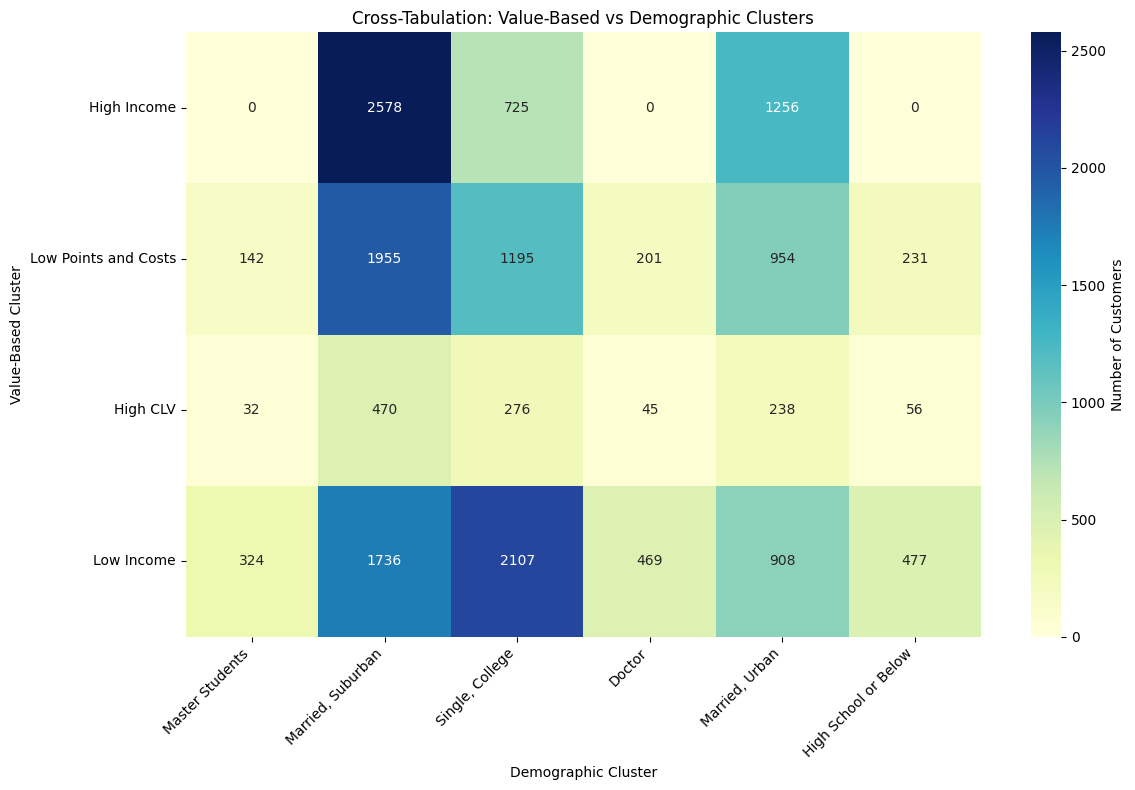

In [30]:
# Define mappings for cluster names from previous visuals
value_cluster_names = {
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
}

demo_cluster_names = {
    0: 'Master Students',
    1: 'Married, Suburban',
    2: 'Single, College',
    3: 'Doctor',
    4: 'Married, Urban',
    5: 'High School or Below'
}


# Create Cross-Tabulation
cross_tab = pd.crosstab(customers['valuebased_cluster'], customers['demographic_cluster'])

# Rename index and columns
cross_tab.rename(index=value_cluster_names, columns=demo_cluster_names, inplace=True)

print("Cross-Tabulation (Value-Based x Demographic):")
display(cross_tab)

# Heatmap Visualization of Cross-Tabulation
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Number of Customers'})
plt.title('Cross-Tabulation: Value-Based vs Demographic Clusters')
plt.xlabel('Demographic Cluster')
plt.ylabel('Value-Based Cluster')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3.1 Merging Clusters
We will now create a new cluster variable that combines both perspectives (e.g., "V0_D1").

In [31]:
# Create new variable 'merged_cluster'
customers['merged_cluster'] = (
    'V' + customers['valuebased_cluster'].astype(str) + 
    '_D' + customers['demographic_cluster'].astype(str)
)

# Number of unique combined clusters
n_merged = customers['merged_cluster'].nunique()
print(f"Number of merged clusters: {n_merged}")

# Show the most frequent combinations
print("\nMost frequent cluster combinations:")
print(customers['merged_cluster'].value_counts().head(10))

Number of merged clusters: 21

Most frequent cluster combinations:
merged_cluster
V0_D1    2578
V3_D2    2107
V1_D1    1955
V3_D1    1736
V0_D4    1256
V1_D2    1195
V1_D4     954
V3_D4     908
V0_D2     725
V3_D5     477
Name: count, dtype: int64


In [32]:
# Profiling of Merged Clusters (Excluding Low Income, Doctors, and High School or Below, Master Students)
# We exclude Value Cluster 3 (Low Income)
# We also exclude Demographic Clusters 3 (Doctor), 4 (High School or Below), and 0 (Master Students) due to low sample size
filtered_customers = customers[
    (customers['valuebased_cluster'] != 3) & 
    (~customers['demographic_cluster'].isin([0, 3, 5 ]))
].copy()

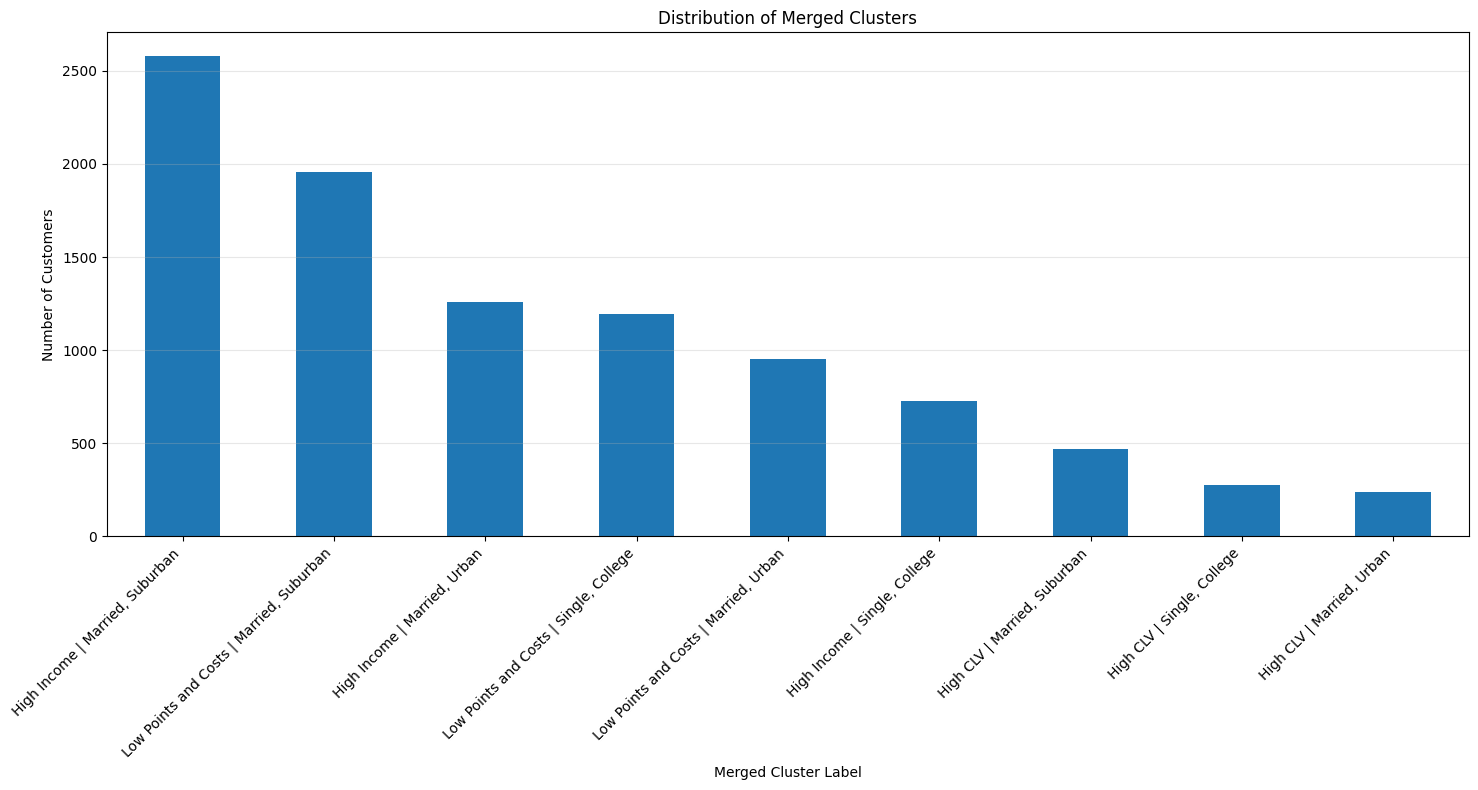

In [33]:
# Visualize distribution of merged clusters with descriptive names

# Define mappings
value_cluster_names = {
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
}
demo_cluster_names = {
    0: 'Master Students',
    1: 'Married, Suburban',
    2: 'Single, College',
    3: 'Doctor',
    4: 'Married, Urban',
    5: 'High School or Below'
}

# Create descriptive labels
filtered_customers['merged_cluster_label'] = (
    filtered_customers['valuebased_cluster'].map(value_cluster_names) + 
    ' | ' + 
    filtered_customers['demographic_cluster'].map(demo_cluster_names)
)

plt.figure(figsize=(15, 8))
filtered_customers['merged_cluster_label'].value_counts().plot(kind='bar')
plt.title('Distribution of Merged Clusters')
plt.xlabel('Merged Cluster Label')
plt.ylabel('Number of Customers')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Strategic Filtering for Actionability

To focus our analysis on the most commercially viable segments, we apply strategic filters:
1.  **Exclusion of Low-Value Tiers:** We exclude the 'Low Income' value cluster to focus resources on segments with higher potential ROI.
2.  **Exclusion of Niche/Small Samples:** We exclude demographic groups with statistically insignificant sample sizes (e.g., 'Doctor', 'High School or Below', 'Master Students') to ensure our recommendations are scalable to the broader customer base.

This leaves us with the core 'Mass Affluent' and 'High Value' segments.


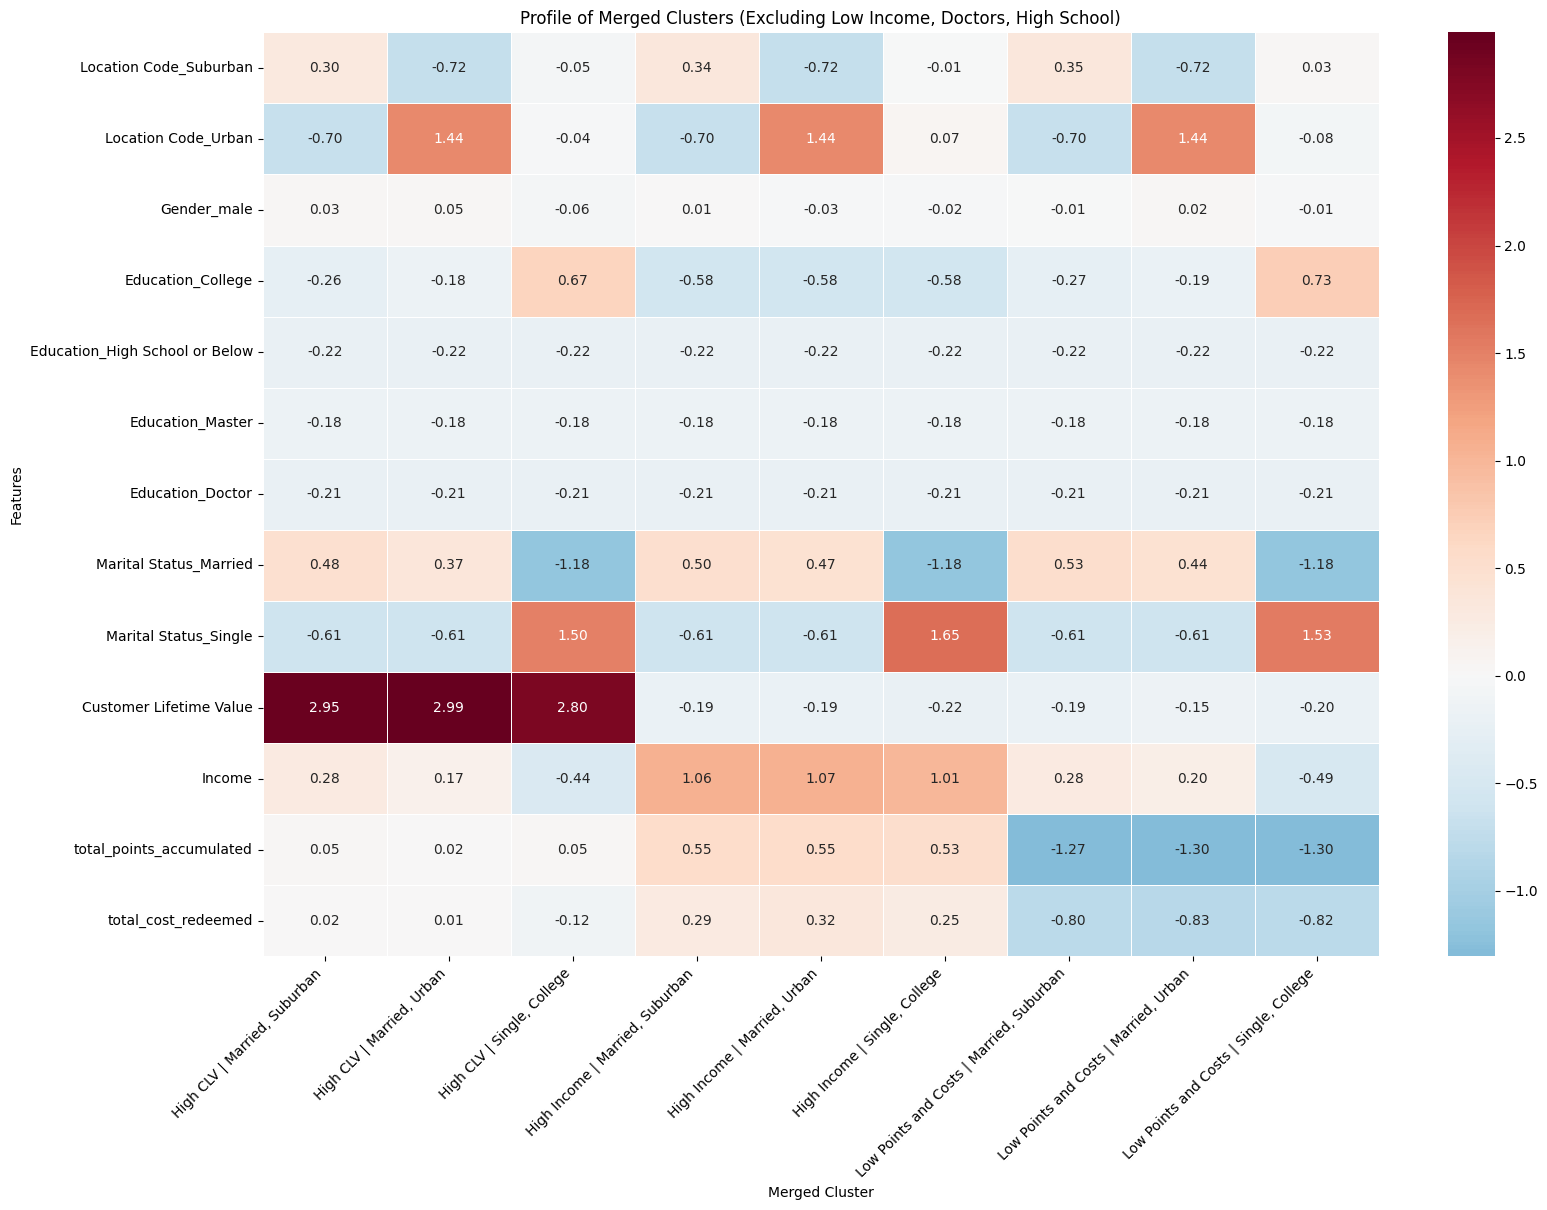

In [39]:
"""# Profiling of Merged Clusters (Excluding Low Income, Doctors, and High School or Below, Master Students)
# We exclude Value Cluster 3 (Low Income)
# We also exclude Demographic Clusters 3 (Doctor), 4 (High School or Below), and 0 (Master Students) due to low sample size
filtered_customers = customers[
    (customers['valuebased_cluster'] != 3) & 
    (~customers['demographic_cluster'].isin([0, 3, 5 ]))
].copy()

# Create descriptive labels for the merged clusters
# Format: "Value Name | Demo Name"
filtered_customers['merged_cluster_label'] = (
    filtered_customers['valuebased_cluster'].map(value_cluster_names) + 
    ' | ' + 
    filtered_customers['demographic_cluster'].map(demo_cluster_names)
)"""

# Calculate means for the remaining merged clusters using the new labels
df_merged_profile = filtered_customers.groupby('merged_cluster_label')[metric_features].mean()

# Z-Score Standardization for the Heatmap (to better see differences)
# We standardize against the global population statistics to see deviations from the overall average
df_merged_profile_std = (df_merged_profile - customers[metric_features].mean()) / customers[metric_features].std()

# Heatmap of the Profile
plt.figure(figsize=(18, 12))
sns.heatmap(
    df_merged_profile_std.T, 
    cmap='RdBu_r', 
    center=0, 
    annot=True, 
    fmt='.2f',
    linewidths=.5
)
plt.title('Profile of Merged Clusters (Excluding Low Income, Doctors, High School)')
plt.xlabel('Merged Cluster')
plt.ylabel('Features')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.show()

### 3.3 Deep Dive Analysis & Strategic Implications

To validate the distinctiveness of our merged segments and derive strategic priorities, we conduct a deep dive using:

1.  **Distribution Analysis (Boxplots):** To assess the internal homogeneity of each segment and identify outliers.
2.  **Strategic Value Matrix (Bubble Chart):** A portfolio analysis tool comparing **Segment Size** (Reach) vs. **Value** (CLV). This helps classify segments into:
    *   **Cash Cows:** Large size, moderate/high value.
    *   **Niche Stars:** Small size, very high value.
    *   **Question Marks:** Segments with potential but lower current engagement.


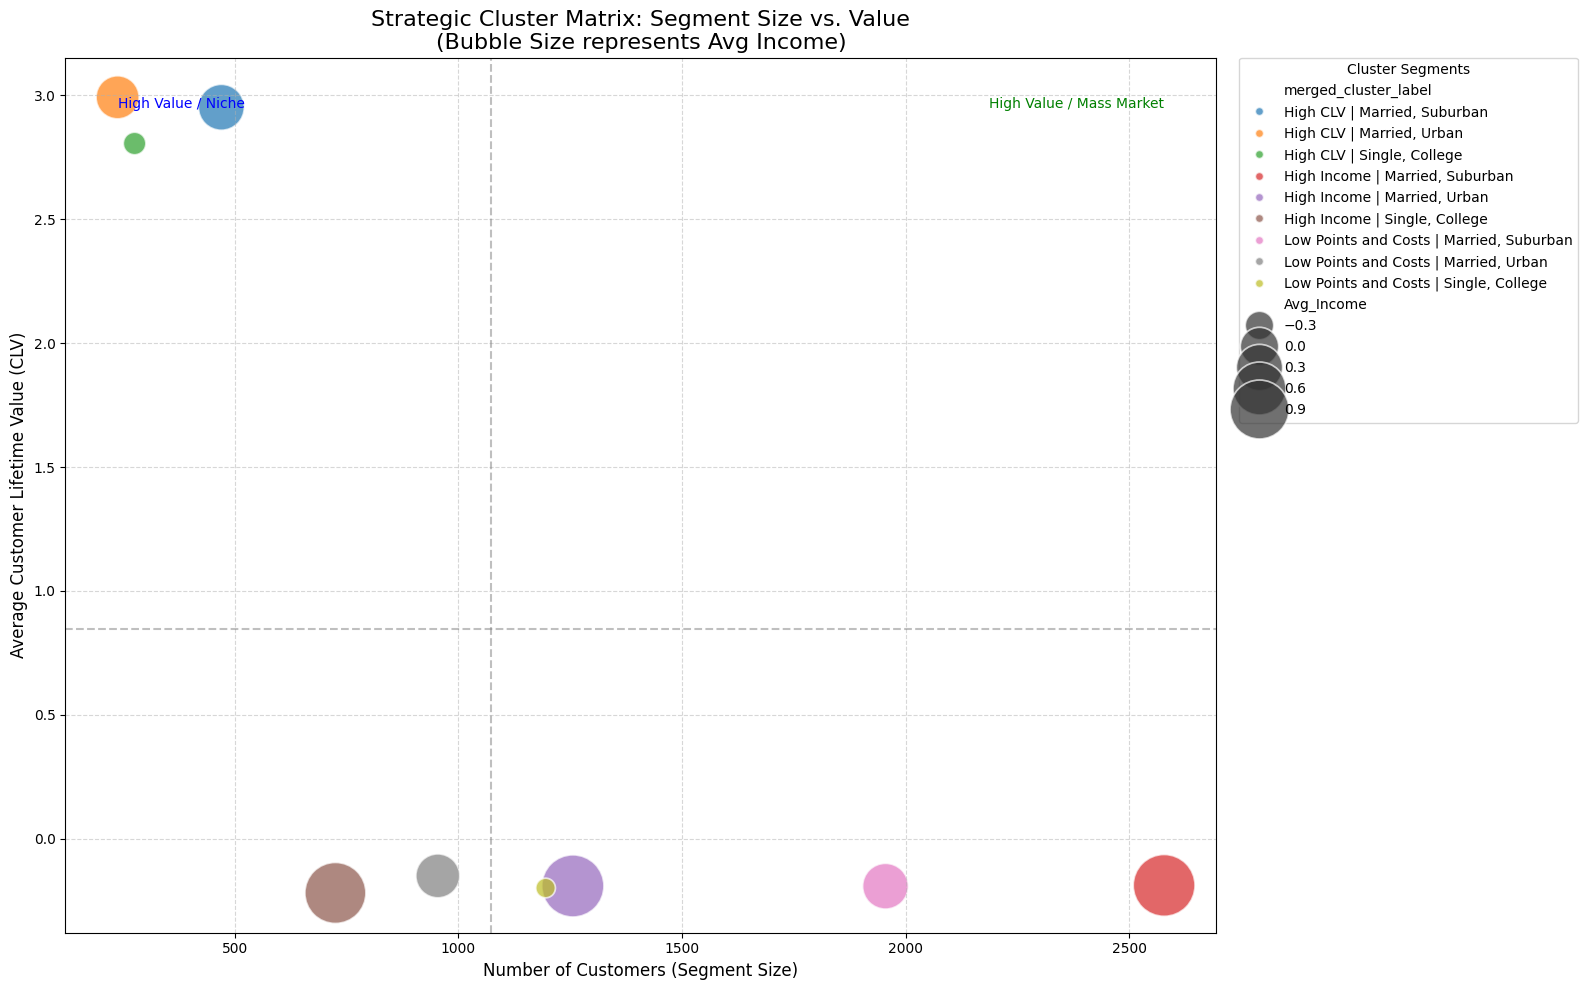

In [ ]:
# --- Visualization 4: Strategic Value Matrix (Bubble Chart) ---
# Purpose: To visualize the trade-off between segment size and value.
# X-Axis: Segment Size (Reach) - How many customers?
# Y-Axis: Average CLV (Value) - How valuable are they?
# Bubble Size: Average Income (Purchasing Power) - Can they afford more?

# 1. Prepare the summary data
# We use reset_index() so 'Loyalty#' becomes a column we can count
strategic_summary = filtered_customers.reset_index().groupby('merged_cluster_label').agg({
    'Customer Lifetime Value': 'mean',
    'Loyalty#': 'count',
    'Income': 'mean'
}).reset_index()

strategic_summary.rename(columns={
    'Loyalty#': 'Count', 
    'Customer Lifetime Value': 'Avg_CLV', 
    'Income': 'Avg_Income'
}, inplace=True)

# 2. Plot
plt.figure(figsize=(16, 10)) # Increased width to accommodate legend
scatter = sns.scatterplot(
    data=strategic_summary, 
    x='Count', 
    y='Avg_CLV', 
    size='Avg_Income', 
    sizes=(200, 2000), # Range of bubble sizes
    hue='merged_cluster_label', 
    palette='tab10',
    alpha=0.7
)

# 3. Legend configuration (Moved outside)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, title='Cluster Segments')

plt.title('Strategic Cluster Matrix: Segment Size vs. Value\n(Bubble Size represents Avg Income)', fontsize=16)
plt.xlabel('Number of Customers (Segment Size)', fontsize=12)
plt.ylabel('Average Customer Lifetime Value (CLV)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Add quadrants (optional, based on mean values)
plt.axvline(x=strategic_summary['Count'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(y=strategic_summary['Avg_CLV'].mean(), color='grey', linestyle='--', alpha=0.5)

plt.text(strategic_summary['Count'].max(), strategic_summary['Avg_CLV'].max(), 'High Value / Mass Market', ha='right', va='top', color='green', fontsize=10)
plt.text(strategic_summary['Count'].min(), strategic_summary['Avg_CLV'].max(), 'High Value / Niche', ha='left', va='top', color='blue', fontsize=10)

plt.tight_layout() # Adjust layout to fit legend
plt.show()


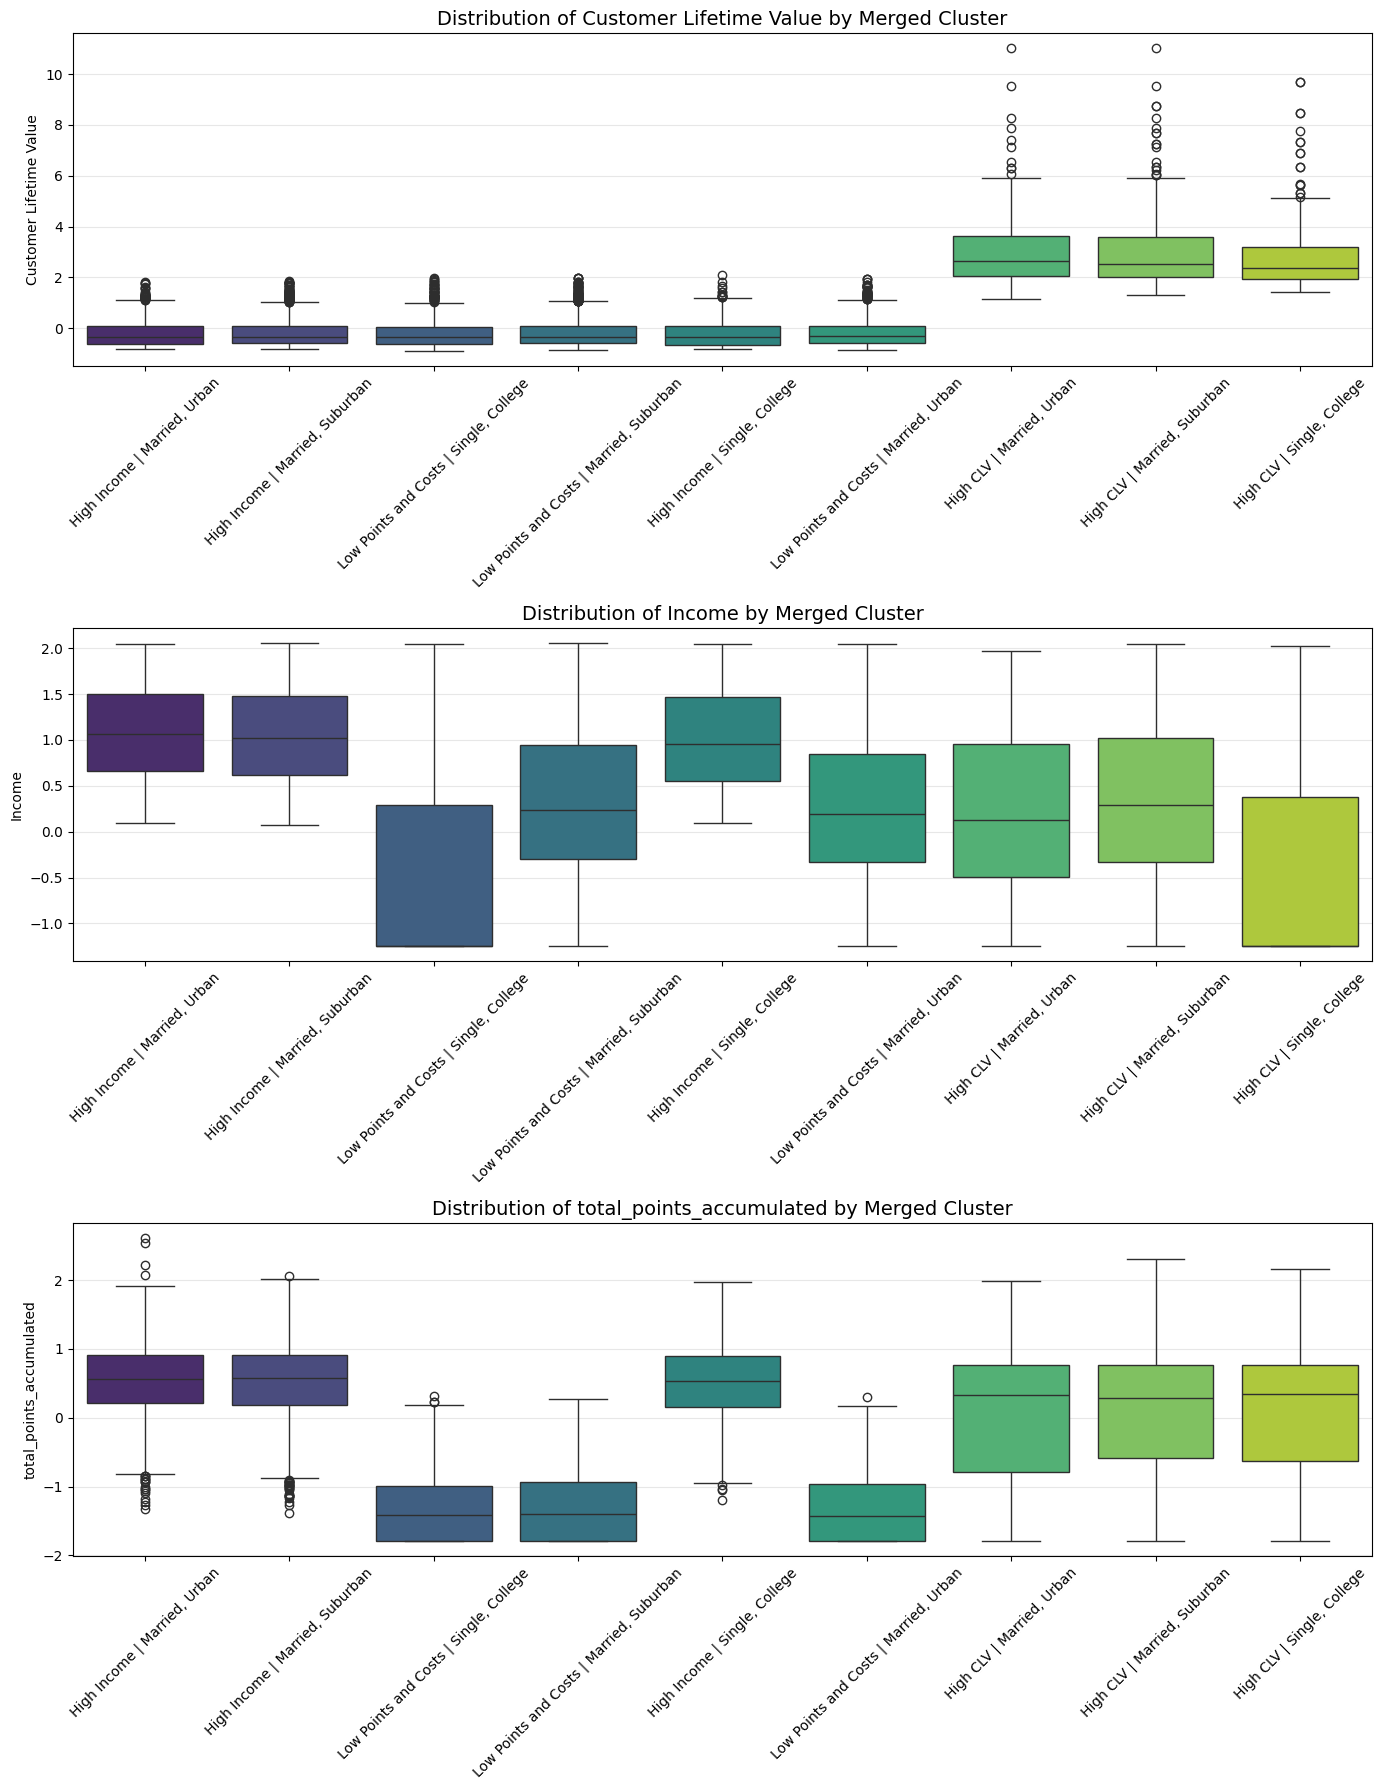

In [36]:
# --- Visualization 3: Distribution of Key Metrics (Boxplots) ---
# This helps us see the spread and outliers within each segment

key_features = ['Customer Lifetime Value', 'Income', 'total_points_accumulated']

fig, axes = plt.subplots(len(key_features), 1, figsize=(14, 6 * len(key_features)))

for i, feature in enumerate(key_features):
    sns.boxplot(
        data=filtered_customers, 
        x='merged_cluster_label', 
        y=feature, 
        ax=axes[i],
        palette='viridis'
    )
    axes[i].set_title(f'Distribution of {feature} by Merged Cluster', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 3.4 Geospatial Analysis

Finally, we map the selected high-priority segments to identify regional concentrations. This geospatial view is critical for:
*   **Regional Marketing Campaigns:** Tailoring offers based on location.
*   **Hub Analysis:** Understanding if high-value customers are clustered around specific airport hubs.


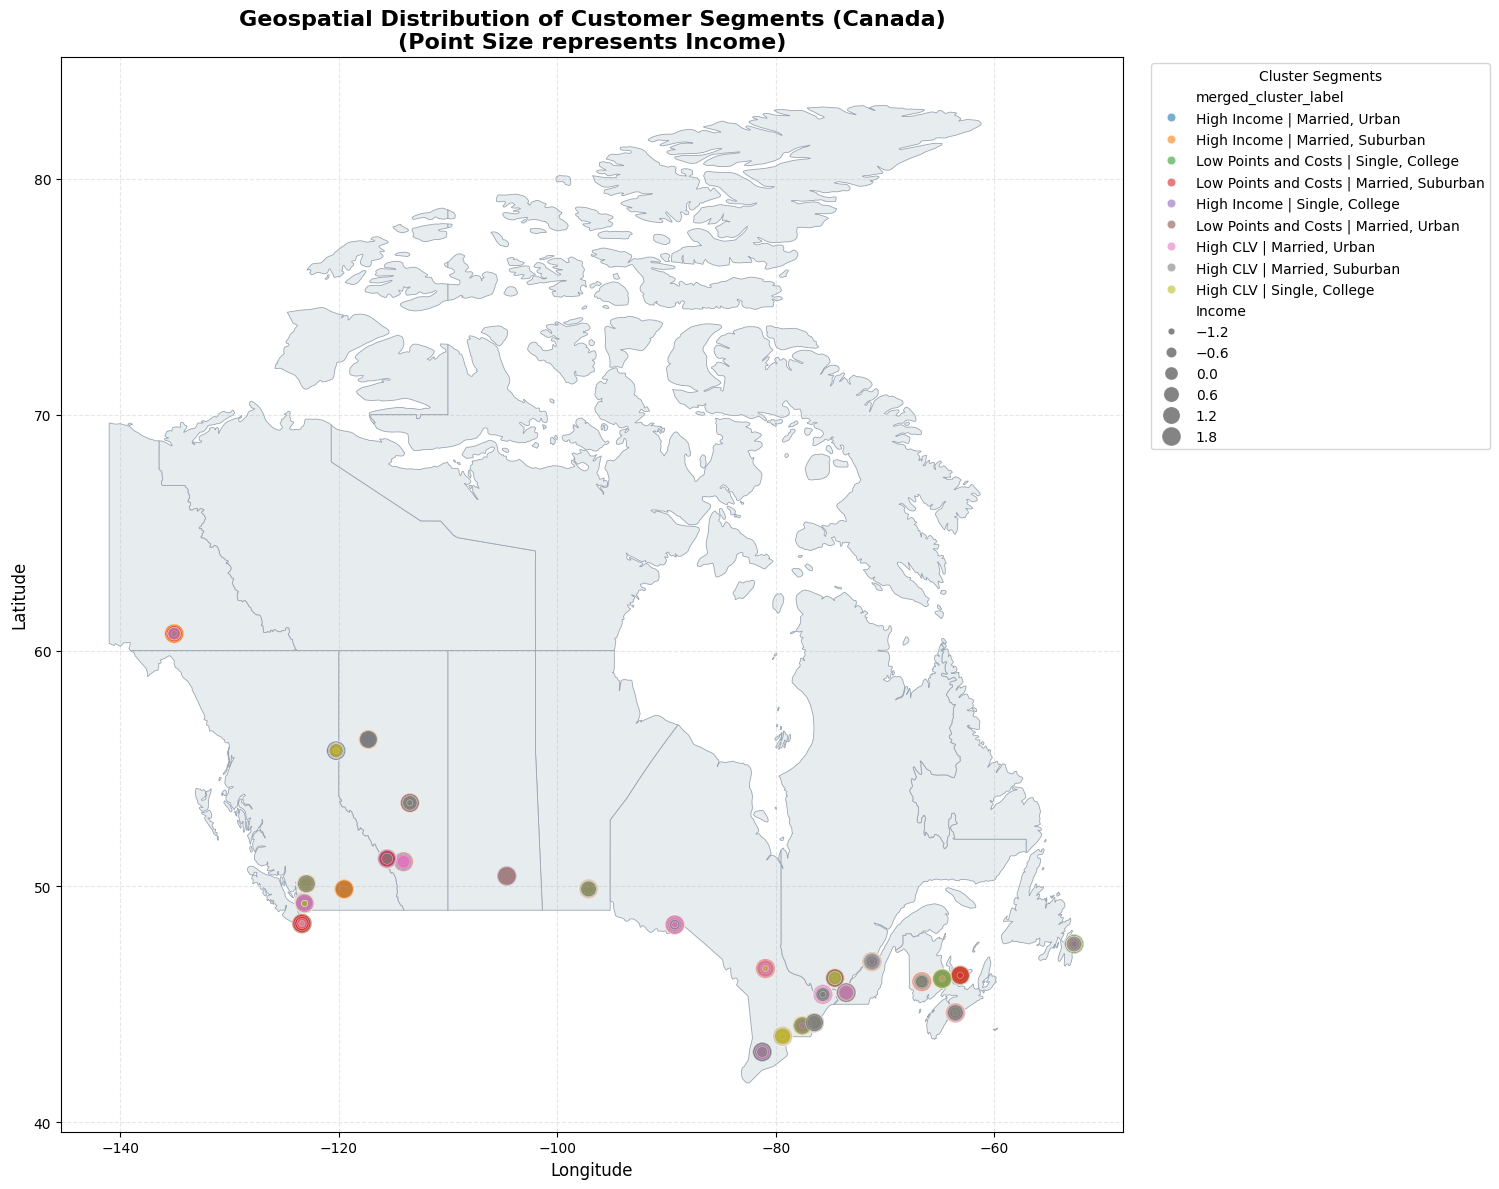

In [ ]:
# --- Visualization 5: Geospatial Distribution of Clusters with Canada Map ---
# Purpose: To map customer segments to physical locations for regional targeting.

# Import geopandas
try:
    import geopandas as gpd
except ImportError:
    # If not installed, you might need to install it:
    # !pip install geopandas
    print("Geopandas not found. Please install it to see the map background.")
    gpd = None

plt.figure(figsize=(16, 12))
ax = plt.gca()

# 1. Load Base Map (Canada)
# Using the code basis from Group92_EDA_Code.ipynb
if gpd:
    try:
        admin1_url = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
        # Read file from URL
        admin1 = gpd.read_file(admin1_url).to_crs("EPSG:4326")
        # Filter for Canada
        canada_admin1 = admin1.loc[admin1["admin"] == "Canada", ["name", "geometry"]].copy()
        
        # Plot the map background
        canada_admin1.plot(ax=ax, color="#E7ECEF", edgecolor="#9AA6B2", linewidth=0.6)
    except Exception as e:
        print(f"Could not load map data: {e}")

# 2. Plot Customer Segments
# We filter out extreme outliers if necessary, but assuming clean data
sns.scatterplot(
    data=filtered_customers, 
    x='Longitude', 
    y='Latitude', 
    hue='merged_cluster_label', 
    size='Income',          # Vary size by Income
    sizes=(20, 200),        # Set size range
    palette='tab10',
    alpha=0.6,
    ax=ax
)

plt.title('Geospatial Distribution of Customer Segments (Canada)\n(Point Size represents Income)', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Cluster Segments')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


## Export the final customers dataframe with clusters 

In [38]:
# Export the final customers DataFrame with clusters
#create a new folder in data folder named 'outputs' and save the file there
import os
output_dir = 'data/outputs'
os.makedirs(output_dir, exist_ok=True)

# Export to CSV
output_path = os.path.join(output_dir, 'customers_with_clusters.csv')
customers.to_csv(output_path, index=False)